In [1]:
# ============================================================
# DECISION TREE FROM SCRATCH
# ============================================================
# A Decision Tree is like a game of '20 Questions'!
#
# It asks a series of yes/no questions about the data:
#   'Is Feature 1 <= 2.5?'
#     YES -> 'Is Feature 2 <= 1.0?' -> ... -> Predict Class 0
#     NO  -> 'Is Feature 1 <= 4.0?' -> ... -> Predict Class 1
#
# The tree LEARNS which questions to ask from training data.
# Each question splits the data into two groups.
# We keep splitting until each group has only one class.
#
# ASCII Diagram of a Decision Tree:
#
#         [Feature 1 <= 2.5?]      <- Root node (first question)
#         /               \
#       YES                NO
#       /                    \
# [Feature 2 <= 1.0?]    [Class = 1]  <- Leaf (answer!)
#    /         \
#  YES          NO
#   |            |
# [Class=0]  [Class=1]             <- Leaf nodes
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print('=' * 60)
print('DECISION TREE FROM SCRATCH')
print('=' * 60)

# ============================================================
# STEP 1: MEASURING IMPURITY
# ============================================================
# Before building the tree, we need a way to measure how
# 'mixed up' (impure) a group of labels is.
#
# PURE group:   [0, 0, 0, 0, 0]  -> All same class -> Great!
# MIXED group:  [0, 0, 1, 1, 0]  -> Mixed classes  -> Bad!
#
# We use TWO measures of impurity:
#
# 1. ENTROPY: From information theory
#    - 0 = perfectly pure (all one class)
#    - 1 = maximally mixed (50/50 split)
#    - Formula: H = -sum( p_i * log2(p_i) )
#
# 2. GINI IMPURITY: Simpler and faster to compute
#    - 0 = perfectly pure
#    - 0.5 = maximally mixed
#    - Formula: G = 1 - sum( p_i^2 )
#
# ANALOGY: Think of a bag of colored balls.
#   Pure bag (all red):            entropy = 0
#   Mixed bag (50% red, 50% blue): entropy = 1
# ============================================================

def entropy(y):
    """
    Compute entropy of a set of labels.

    Entropy = -sum( p_i * log2(p_i) )
    where p_i = fraction of examples belonging to class i

    Returns: 0 (pure) to 1 (maximally mixed)
    """

    # STEP 1a: Count how many times each class appears
    # np.unique returns:
    #   classes = unique values (e.g. [0, 1])
    #   counts  = how many of each (e.g. [3, 2])
    classes, counts = np.unique(y, return_counts=True)

    # STEP 1b: Convert counts to probabilities
    # e.g. [3, 2] out of 5 -> [0.6, 0.4]
    probabilities = counts / len(y)

    # STEP 1c: Apply entropy formula: H = -sum( p * log2(p) )
    # log2(1.0) = 0  -> pure node has entropy = 0
    # log2(0.5) = -1 -> 50/50 split has entropy = 1
    entropy_val = 0
    for p in probabilities:
        if p > 0:                   # Avoid log(0) which is undefined!
            entropy_val -= p * np.log2(p)

    return entropy_val


def gini_impurity(y):
    """
    Compute Gini impurity.

    Gini = 1 - sum( p_i^2 )
    Intuition: probability of mislabeling a random sample.

    Returns: 0 (pure) to 0.5 (maximally mixed for 2 classes)
    """

    # Count each class and compute probabilities
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)

    # Gini = 1 - sum(p^2)
    # Pure node:    G = 1 - 1^2 = 0
    # 50/50 split:  G = 1 - (0.5^2 + 0.5^2) = 0.5
    gini = 1 - np.sum(probabilities ** 2)

    return gini


# ============================================================
# TEST: Verify on known examples
# ============================================================
# Expected:
#   Pure sets -> entropy=0, gini=0
#   50/50 split -> entropy=1, gini=0.5
# ============================================================

print('\n' + '=' * 60)
print('Testing Entropy & Gini Calculations')
print('=' * 60)

test_cases = [
    ([0, 0, 0, 0, 0], 'Pure (all 0s)'),
    ([1, 1, 1, 1, 1], 'Pure (all 1s)'),
    ([0, 0, 0, 0, 1], 'Mostly 0s'),
    ([0, 0, 0, 1, 1], '60-40 split'),
    ([0, 0, 1, 1, 1], '40-60 split'),
    ([0, 1, 0, 1, 0], '50-50 split'),
]

for labels, description in test_cases:
    y = np.array(labels)
    ent = entropy(y)
    gini = gini_impurity(y)
    print(f'{description:20s} | Entropy: {ent:.4f} | Gini: {gini:.4f}')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Pure nodes (all one class)  -> entropy=0, gini=0
# 2. Mixed nodes (many classes)  -> higher entropy/gini
# 3. The tree tries to CREATE pure nodes by splitting data
# 4. Entropy uses log2 (slower), Gini uses squares (faster)
# 5. Both give similar results in practice
# ============================================================


DECISION TREE FROM SCRATCH

Testing Entropy & Gini Calculations
Pure (all 0s)        | Entropy: 0.0000 | Gini: 0.0000
Pure (all 1s)        | Entropy: 0.0000 | Gini: 0.0000
Mostly 0s            | Entropy: 0.7219 | Gini: 0.3200
60-40 split          | Entropy: 0.9710 | Gini: 0.4800
40-60 split          | Entropy: 0.9710 | Gini: 0.4800
50-50 split          | Entropy: 0.9710 | Gini: 0.4800


In [2]:
# ============================================================
# STEP 2: INFORMATION GAIN
# ============================================================
# We can measure impurity. But HOW do we choose which split?
#
# Answer: Pick the split that REDUCES impurity the most!
# This reduction is called INFORMATION GAIN.
#
# Information Gain = Parent Impurity - Weighted Child Impurity
#
# Example (perfect split):
#   Parent: [0,0,0,0,1,1,1,1]    <- entropy = 1.0 (50/50 mixed)
#          /              \
#   Left: [0,0,0,0]   Right: [1,1,1,1]
#   entropy=0.0        entropy=0.0
#
#   Gain = 1.0 - (4/8)*0.0 - (4/8)*0.0 = 1.0  <- PERFECT!
#
# Example (useless split):
#   Parent: [0,0,0,0,1,1,1,1]    <- entropy = 1.0
#          /              \
#   Left: [0,0,1,1]   Right: [0,0,1,1]
#   entropy=1.0        entropy=1.0
#
#   Gain = 1.0 - (4/8)*1.0 - (4/8)*1.0 = 0.0  <- USELESS!
#
# We always pick the split with HIGHEST information gain!
# ============================================================

def information_gain(y, left_y, right_y, criterion='entropy'):
    """
    Compute information gain from a split.

    IG = H(parent) - [ (n_left/n)*H(left) + (n_right/n)*H(right) ]

    The second term is a WEIGHTED average because larger child
    nodes should count more than smaller ones.

    Returns: gain (higher = better split)
    """

    # STEP 1: Choose which impurity measure to use
    if criterion == 'entropy':
        impurity_fn = entropy
    else:
        impurity_fn = gini_impurity

    # STEP 2: Compute the PARENT node impurity (before split)
    parent_impurity = impurity_fn(y)

    # STEP 3: Get sizes for the weighted average
    n = len(y)
    n_left = len(left_y)
    n_right = len(right_y)

    # STEP 4: Weighted average impurity of children
    # Why weighted? A split sending 90 left and 10 right should
    # weight the left child's impurity much more heavily!
    weighted_child_impurity = (n_left / n) * impurity_fn(left_y) + \
                               (n_right / n) * impurity_fn(right_y)

    # STEP 5: Gain = how much impurity we REDUCED
    # Positive = split helped (children purer than parent)
    # Zero     = split was useless
    gain = parent_impurity - weighted_child_impurity

    return gain


# ============================================================
# TEST: Verify on known examples
# ============================================================

print('\n' + '=' * 60)
print('Testing Information Gain')
print('=' * 60)

y = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 50/50 parent
print(f'Parent: {y}')
print(f'Parent entropy: {entropy(y):.4f}')

# Perfect split
left1 = np.array([0, 0, 0, 0])
right1 = np.array([1, 1, 1, 1])
gain1 = information_gain(y, left1, right1)
print(f'\nSplit 1 (perfect): Left={left1}, Right={right1}')
print(f'Information Gain: {gain1:.4f} (should be 1.0)')

# Useless split
left2 = np.array([0, 0, 1, 1])
right2 = np.array([0, 0, 1, 1])
gain2 = information_gain(y, left2, right2)
print(f'\nSplit 2 (bad): Left={left2}, Right={right2}')
print(f'Information Gain: {gain2:.4f} (should be 0.0)')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Information Gain measures how useful a split is
# 2. Gain = 1.0  ->  PERFECT split (pure children)
# 3. Gain = 0.0  ->  USELESS split (no improvement)
# 4. The tree always picks the split with MAXIMUM gain
# 5. Weighted average because split sizes matter
# ============================================================



Testing Information Gain
Parent: [0 0 0 0 1 1 1 1]
Parent entropy: 1.0000

Split 1 (perfect): Left=[0 0 0 0], Right=[1 1 1 1]
Information Gain: 1.0000 (should be 1.0)

Split 2 (bad): Left=[0 0 1 1], Right=[0 0 1 1]
Information Gain: 0.0000 (should be 0.0)


In [3]:
# ============================================================
# STEP 3: FINDING THE BEST SPLIT
# ============================================================
# We know how to measure information gain.
# Now: try EVERY possible split and pick the best one!
#
# A 'split' means:
#   - Pick a FEATURE  (which column to look at)
#   - Pick a THRESHOLD (what value to split at)
#   - Left:  examples where feature <= threshold
#   - Right: examples where feature >  threshold
#
# We use MIDPOINTS between consecutive unique values as thresholds.
# Example: unique values [1.2, 1.9, 2.5]
#   -> thresholds: (1.2+1.9)/2=1.55,  (1.9+2.5)/2=2.2
#
# We try ALL features x ALL thresholds and keep the BEST!
# ============================================================

def find_best_split(X, y, criterion='entropy'):
    """
    Find the best feature and threshold to split on.

    Tries every feature x every midpoint threshold,
    returns the one with the highest information gain.

    Returns:
        best_feature:   column index to split on
        best_threshold: value to compare against
        best_gain:      information gain of the best split
    """

    # STEP 1: Get data dimensions
    # m = number of examples (rows)
    # n = number of features (columns)
    m, n = X.shape

    # STEP 2: Start with no best split found yet
    best_gain = -1        # Any real gain will beat -1
    best_feature = None
    best_threshold = None

    # STEP 3: Loop over every feature
    for feature_idx in range(n):
        feature_values = X[:, feature_idx]   # One column
        unique_values = np.unique(feature_values)  # Sorted unique values

        # STEP 4: Try midpoints between consecutive unique values
        # Using midpoints ensures the threshold is always between two data points
        for i in range(len(unique_values) - 1):
            threshold = (unique_values[i] + unique_values[i + 1]) / 2

            # STEP 5: Split data at this threshold
            left_mask  = feature_values <= threshold
            right_mask = feature_values >  threshold

            # Skip if one side is empty (a split with nothing is useless)
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            left_y  = y[left_mask]
            right_y = y[right_mask]

            # STEP 6: Compute information gain for this split
            gain = information_gain(y, left_y, right_y, criterion)

            # STEP 7: Keep this split if it's the best so far
            if gain > best_gain:
                best_gain      = gain
                best_feature   = feature_idx
                best_threshold = threshold

    # Return the single best split found across all features
    return best_feature, best_threshold, best_gain

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. We try EVERY feature x EVERY threshold combination
# 2. We use midpoints so thresholds fall between data points
# 3. We keep track of the best gain seen so far
# 4. This is an O(n * m * log m) operation per node
#    (can be slow for large datasets — that's why real
#     implementations use tricks to speed this up!)
# ============================================================


In [4]:
# ============================================================
# STEP 4: THE NODE CLASS
# ============================================================
# A decision tree is made up of NODES connected together.
# There are two types:
#
# 1. INTERNAL NODE (decision node)
#    - Asks a question: 'Is Feature 2 <= 1.5?'
#    - Has a LEFT child  (YES branch)
#    - Has a RIGHT child (NO branch)
#
# 2. LEAF NODE (terminal node)
#    - Gives an answer: 'Class = 1'
#    - Has NO children
#    - This is where predictions come from!
#
# ASCII Diagram:
#
#  [Feature 0 <= 2.0?]   <- Internal node (has feature + threshold)
#     /          \
#   YES           NO
#   /               \
# [Leaf: 0]   [Feature 1 <= 1.5?]   <- Another internal node
#                 /         \
#               YES           NO
#               /               \
#          [Leaf: 0]         [Leaf: 1]
#
# ============================================================

class Node:
    """
    A single node in the decision tree.

    Internal node: splits data on a feature threshold (has children)
    Leaf node:     stores a class prediction (no children)
    """

    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        # --- For INTERNAL nodes ---
        self.feature   = feature    # Which column to split on (e.g. 0 = first feature)
        self.threshold = threshold  # The cutoff value (e.g. 2.5)
        self.left      = left       # Left subtree  (examples where feature <= threshold)
        self.right     = right      # Right subtree (examples where feature >  threshold)

        # --- For LEAF nodes ---
        self.value = value          # Class prediction (e.g. 0 or 1)
        # If value is not None -> this is a leaf!

    def is_leaf(self):
        """
        Returns True if this is a leaf node (has a prediction).
        Returns False if this is an internal node (has a question).

        How it works:
          Leaf nodes have value set (e.g. 0 or 1)
          Internal nodes have value=None
        """
        return self.value is not None

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Every node is either a QUESTION (internal) or ANSWER (leaf)
# 2. Internal nodes split data left/right using a threshold
# 3. Leaf nodes store the final class prediction
# 4. is_leaf() lets us check which type a node is
# 5. The whole tree is just nodes connected together!
# ============================================================


In [5]:
# ============================================================
# STEP 5: THE DECISION TREE CLASS
# ============================================================
# Now we put everything together!
#
# The tree is built RECURSIVELY — the function calls itself
# to build smaller and smaller sub-trees.
#
# HOW BUILDING WORKS:
#   1. Start with ALL data at the root
#   2. Find the best split (best feature + threshold)
#   3. Split data into LEFT and RIGHT groups
#   4. Recursively build a sub-tree for the LEFT group
#   5. Recursively build a sub-tree for the RIGHT group
#   6. Stop when a stopping condition is met:
#      a) All examples have the same class (pure node)
#      b) Max depth reached
#      c) Too few examples to split
#      d) No split improves things (gain = 0)
#
# HOW PREDICTION WORKS:
#   Walk down the tree answering questions until you hit a leaf.
#   The leaf's value is the prediction!
# ============================================================

class DecisionTree:
    """Decision Tree Classifier built from scratch."""

    def __init__(self, max_depth=None, min_samples_split=2, criterion='entropy'):
        # max_depth: how deep the tree can grow
        #   None = unlimited (risks overfitting!)
        #   2    = at most 2 levels of questions
        self.max_depth = max_depth

        # min_samples_split: minimum examples needed before splitting
        #   2  = always try to split (default)
        #   10 = only split if >= 10 examples are present
        self.min_samples_split = min_samples_split

        # criterion: which impurity measure to use
        self.criterion = criterion

        # root: top node of the tree, filled in by fit()
        self.root = None

    # ----------------------------------------------------------
    # FIT: Build the tree from training data
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Build the decision tree.
        Kick off the recursive tree-building starting at depth 0.
        """
        self.root = self._build_tree(X, y, depth=0)
        return self

    # ----------------------------------------------------------
    # _BUILD_TREE: The recursive workhorse
    # ----------------------------------------------------------
    def _build_tree(self, X, y, depth):
        """
        Recursively build the tree.
        Either returns a leaf (if stopping condition) or
        finds the best split and recurses on both halves.
        """
        m, n = X.shape
        n_classes = len(np.unique(y))  # How many distinct classes?

        # ---- STOPPING CONDITIONS (return a leaf) ----

        # Condition 1: Pure node — all examples are the same class
        # No need to split; we already know the answer!
        if n_classes == 1:
            return Node(value=y[0])

        # Condition 2: Reached maximum depth
        # Prevents the tree from growing too deep (avoids overfitting)
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=self._most_common_class(y))

        # Condition 3: Too few examples to split
        if m < self.min_samples_split:
            return Node(value=self._most_common_class(y))

        # ---- FIND THE BEST SPLIT ----

        # Try every feature x threshold; return best one
        best_feature, best_threshold, best_gain = find_best_split(X, y, self.criterion)

        # Condition 4: No split helps
        if best_gain == 0:
            return Node(value=self._most_common_class(y))

        # ---- SPLIT THE DATA ----

        # Boolean masks: True for examples that go left / right
        left_mask  = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] >  best_threshold

        X_left,  y_left  = X[left_mask],  y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]

        # ---- RECURSIVELY BUILD SUBTREES ----
        # Each call handles one branch; depth+1 tracks how deep we are
        left_subtree  = self._build_tree(X_left,  y_left,  depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)

        # Return an internal node connecting this split to its children
        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )

    # ----------------------------------------------------------
    # HELPER: Pick the majority class (used at leaf nodes)
    # ----------------------------------------------------------
    def _most_common_class(self, y):
        """
        Return the most frequent class in y.
        Like majority voting — predict whatever class appears most.
        """
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    # ----------------------------------------------------------
    # PREDICT: Classify new examples
    # ----------------------------------------------------------
    def predict(self, X):
        """Walk down the tree for each example and return predictions."""
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        """
        Walk down the tree for a single example x.

        At each internal node:
          Go LEFT  if x[feature] <= threshold  (YES answer)
          Go RIGHT if x[feature] >  threshold  (NO answer)
        Keep going until we hit a leaf!
        """
        # Base case: reached a leaf -> return its prediction
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)   # Go LEFT (YES)
        else:
            return self._traverse_tree(x, node.right)  # Go RIGHT (NO)

    # ----------------------------------------------------------
    # PRINT_TREE: Show the tree structure as text
    # ----------------------------------------------------------
    def print_tree(self, node=None, depth=0):
        """Print a human-readable view of what the tree learned."""
        if node is None:
            node = self.root

        indent = '  ' * depth
        if node.is_leaf():
            print(f'{indent}Leaf: class = {node.value}')
        else:
            print(f'{indent}Feature {node.feature} <= {node.threshold:.3f}?')
            print(f'{indent}|-- True (YES):')
            self.print_tree(node.left,  depth + 1)
            print(f'{indent}|-- False (NO):')
            self.print_tree(node.right, depth + 1)

print('\n' + '=' * 60)
print('Decision Tree Implementation Complete!')
print('=' * 60)

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. fit() kicks off _build_tree() recursively from the root
#
# 2. STOPPING CONDITIONS prevent infinite recursion:
#    - Pure node, max depth, too few samples, no gain
#
# 3. DEEPER tree = more complex = risk of overfitting
#    SHALLOWER tree = simpler   = risk of underfitting
#
# 4. predict() walks down the tree asking questions
#    until reaching a leaf — then returns that leaf's class
# ============================================================



Decision Tree Implementation Complete!



Testing Decision Tree on 2D Dataset
Dataset: 100 examples, 2 features
Class 0: 50 examples
Class 1: 50 examples

Depth = 1:
Accuracy: 100.0%
Tree structure:
Feature 0 <= 1.915?
|-- True (YES):
  Leaf: class = 0.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 2:
Accuracy: 100.0%
Tree structure:
Feature 0 <= 1.915?
|-- True (YES):
  Leaf: class = 0.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 3:
Accuracy: 100.0%

Depth = unlimited:
Accuracy: 100.0%


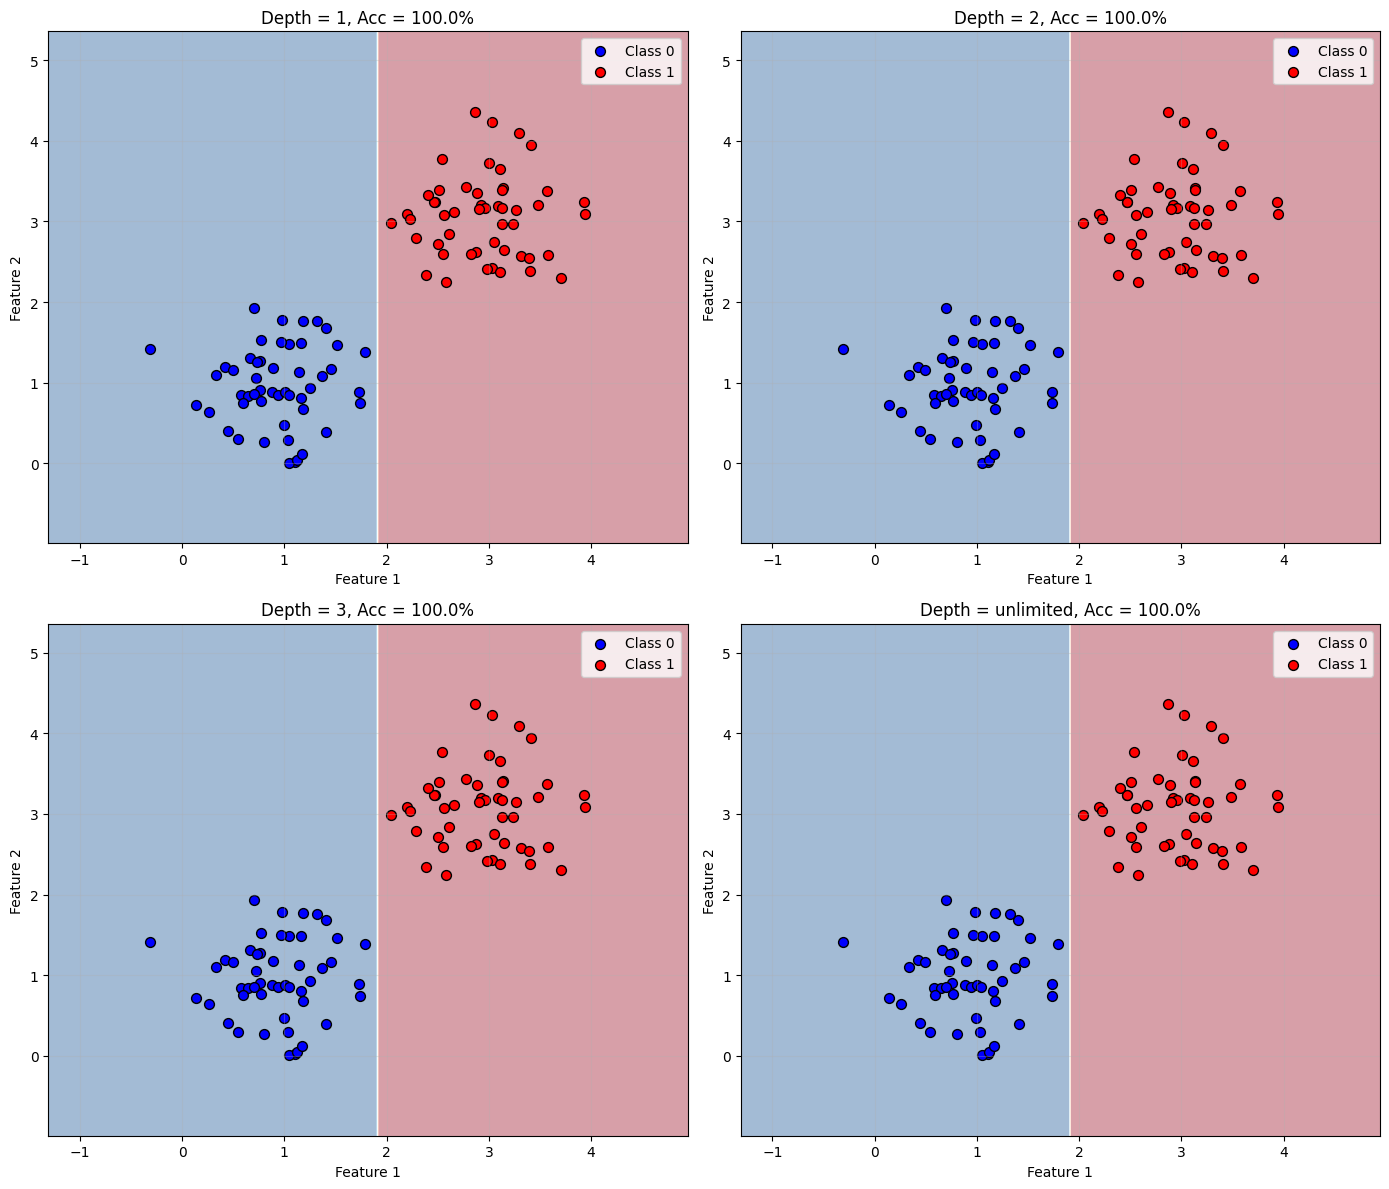


Decision Tree Test Complete!
All plots look the same because depth=1 already solves this easy data!


In [6]:
# ============================================================
# TESTING ON A SIMPLE (LINEARLY SEPARABLE) DATASET
# ============================================================
# Class 0: clustered around (1, 1)  — bottom-left
# Class 1: clustered around (3, 3)  — top-right
#
# These two clusters are far apart, so a SINGLE vertical cut
# at x~2 already separates them perfectly.
# That is why ALL depths give 100% accuracy and look the same!
#
# The NEXT cell uses an XOR dataset that actually needs
# multiple splits to show interesting depth differences.
# ============================================================

print('\n' + '=' * 60)
print('Testing Decision Tree on 2D Dataset')
print('=' * 60)

np.random.seed(42)

# Class 0: 50 points near (1, 1) with small Gaussian noise
X_class0 = np.random.randn(50, 2) * 0.5 + np.array([1, 1])
y_class0 = np.zeros(50)

# Class 1: 50 points near (3, 3) with small Gaussian noise
X_class1 = np.random.randn(50, 2) * 0.5 + np.array([3, 3])
y_class1 = np.ones(50)

# Combine and shuffle
X = np.vstack([X_class0, X_class1])   # Stack rows -> (100, 2)
y = np.hstack([y_class0, y_class1])   # Concatenate -> (100,)
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

print(f'Dataset: {len(X)} examples, 2 features')
print(f'Class 0: {int(np.sum(y==0))} examples')
print(f'Class 1: {int(np.sum(y==1))} examples')

# ============================================================
# Train at depths 1, 2, 3, unlimited and plot boundaries
# ============================================================

depths = [1, 2, 3, None]  # None = unlimited depth

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Turn 2x2 grid into a flat list of 4 axes

for idx, max_depth in enumerate(depths):

    # Train a fresh tree
    tree = DecisionTree(max_depth=max_depth, criterion='entropy')
    tree.fit(X, y)

    # Measure accuracy on training data
    y_pred = tree.predict(X)
    accuracy = np.mean(y_pred == y) * 100

    print(f'\nDepth = {max_depth if max_depth else "unlimited"}:')
    print(f'Accuracy: {accuracy:.1f}%')

    if max_depth and max_depth <= 2:
        print('Tree structure:')
        tree.print_tree()

    # ---- Visualise the decision boundary ----
    ax = axes[idx]

    # Build a dense grid covering the feature space
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    # Predict every point on the grid to colour regions
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')  # Colour background
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=50, edgecolors='black', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red',  s=50, edgecolors='black', label='Class 1')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Depth = {max_depth if max_depth else "unlimited"}, Acc = {accuracy:.1f}%')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDecision Tree Test Complete!')
print('All plots look the same because depth=1 already solves this easy data!')


Testing Decision Tree on XOR Dataset
Dataset: 200 examples, 2 features
Class 0: 100 | Class 1: 100
XOR pattern: depth=1 gets ~50%, needs depth=2+ to separate!

Depth = 1: Accuracy = 52.0%
Tree structure:
Feature 0 <= 3.203?
|-- True (YES):
  Leaf: class = 0.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 2: Accuracy = 52.5%
Tree structure:
Feature 0 <= 3.203?
|-- True (YES):
  Feature 1 <= -2.644?
  |-- True (YES):
    Leaf: class = 0.0
  |-- False (NO):
    Leaf: class = 1.0
|-- False (NO):
  Leaf: class = 1.0

Depth = 3: Accuracy = 59.5%
Depth = unlimited: Accuracy = 100.0%


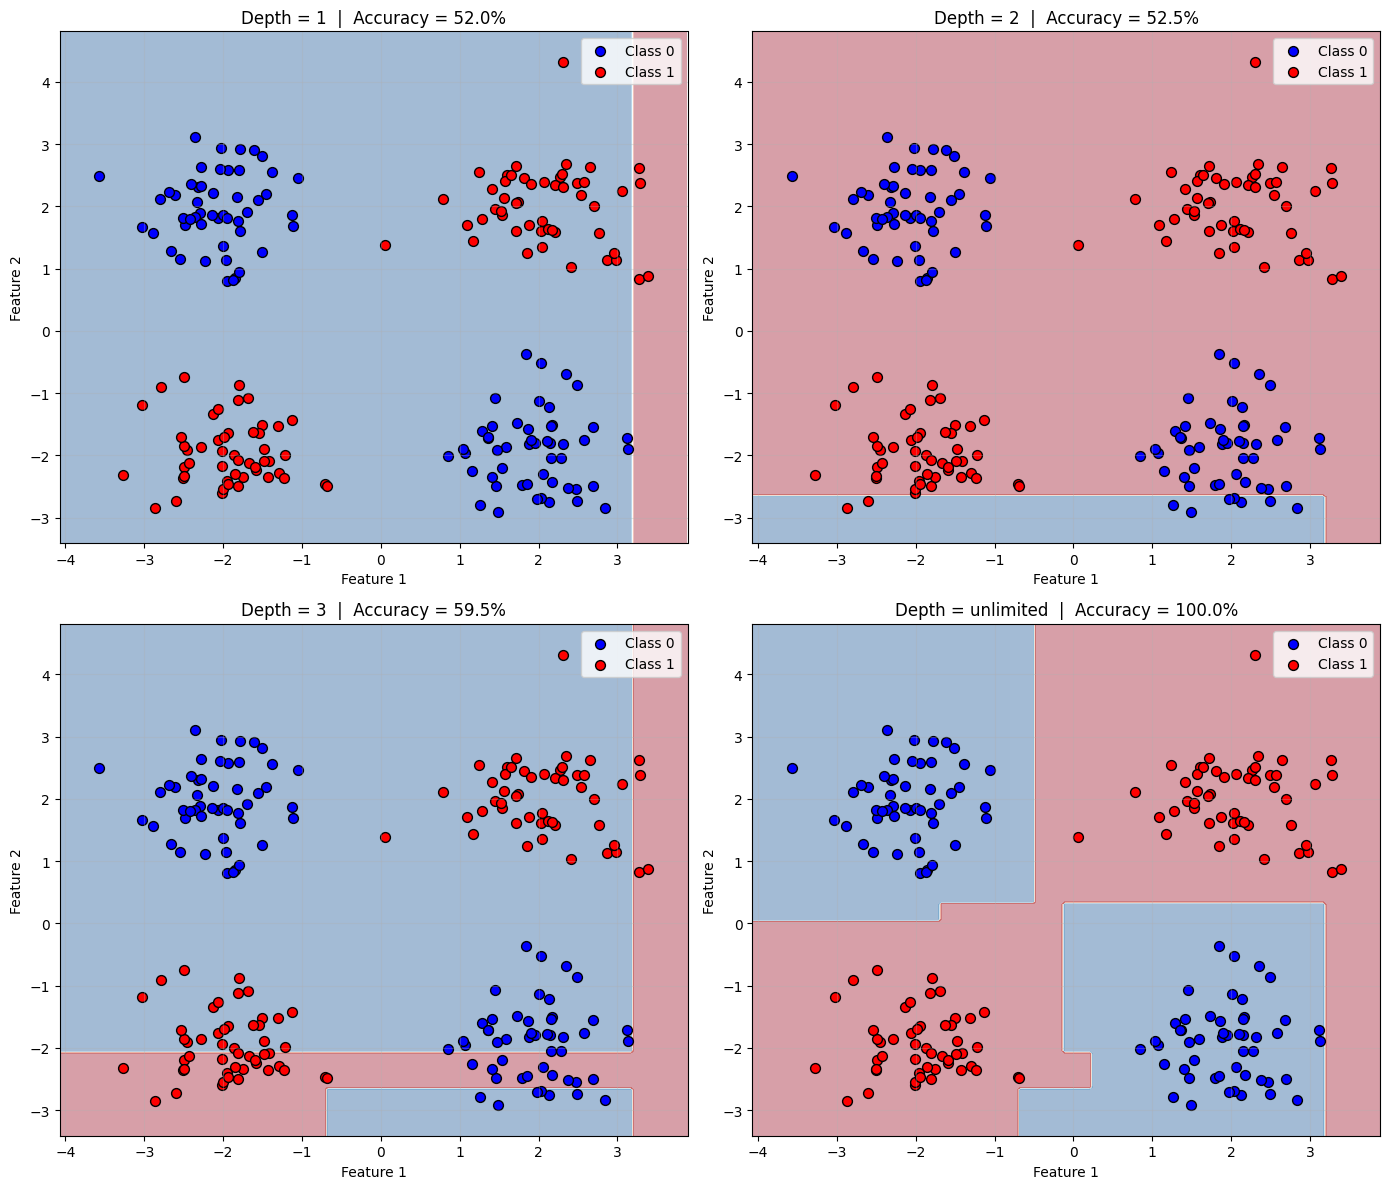


Decision Tree Test Complete!


In [7]:
# ============================================================
# TESTING ON AN XOR DATASET (requires depth >= 2)
# ============================================================
# XOR = Exclusive OR. The pattern looks like a checkerboard:
#
#   Feature 2
#     ^
#   + | [0][0] | [1][1]
#     | [0][0] | [1][1]
#   0 |---------+-------->  Feature 1
#     | [1][1] | [0][0]
#   - | [1][1] | [0][0]
#
# Class 0: top-left  + bottom-right quadrants
# Class 1: top-right + bottom-left  quadrants
#
# WHY IS THIS HARD?
#   Depth=1 makes ONE cut (left/right OR up/down)
#   -> Both halves still contain both classes -> ~50% accuracy
#
#   Depth=2 makes TWO cuts (a cross shape)
#   -> Each quadrant is now pure -> ~100% accuracy
#
# This is a great demo of WHY depth matters!
# ============================================================

np.random.seed(42)

print('=' * 60)
print('Testing Decision Tree on XOR Dataset')
print('=' * 60)

n = 50  # Points per cluster

# Class 0: top-left and bottom-right (opposite corners)
X0a = np.random.randn(n, 2) * 0.6 + np.array([-2,  2])  # top-left
X0b = np.random.randn(n, 2) * 0.6 + np.array([ 2, -2])  # bottom-right

# Class 1: top-right and bottom-left (other two corners)
X1a = np.random.randn(n, 2) * 0.6 + np.array([ 2,  2])  # top-right
X1b = np.random.randn(n, 2) * 0.6 + np.array([-2, -2])  # bottom-left

# Combine all 4 clusters: 200 examples total
X = np.vstack([X0a, X0b, X1a, X1b])
y = np.hstack([np.zeros(n * 2), np.ones(n * 2)])  # 100 class-0, 100 class-1

# Shuffle so classes are mixed in order
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

print(f'Dataset: {len(X)} examples, 2 features')
print(f'Class 0: {int(np.sum(y==0))} | Class 1: {int(np.sum(y==1))}')
print('XOR pattern: depth=1 gets ~50%, needs depth=2+ to separate!\n')

# ============================================================
# Train at depths 1, 2, 3, unlimited and compare
# ============================================================

depths = [1, 2, 3, None]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, max_depth in enumerate(depths):

    # Train tree
    tree = DecisionTree(max_depth=max_depth, criterion='entropy')
    tree.fit(X, y)

    y_pred = tree.predict(X)
    accuracy = np.mean(y_pred == y) * 100

    label = str(max_depth) if max_depth else 'unlimited'
    print(f'Depth = {label}: Accuracy = {accuracy:.1f}%')

    # Print the tree structure for shallow trees so we can read it
    if max_depth and max_depth <= 2:
        print('Tree structure:')
        tree.print_tree()
        print()

    # ---- Visualise decision boundary ----
    ax = axes[idx]
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    # Colour every grid point by predicted class
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=50, edgecolors='black', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red',  s=50, edgecolors='black', label='Class 1')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Depth = {label}  |  Accuracy = {accuracy:.1f}%')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDecision Tree Test Complete!')

# ============================================================
# KEY TAKEAWAYS FROM THIS NOTEBOOK:
# ============================================================
# 1. Decision Trees ask yes/no questions to classify data
#
# 2. ENTROPY & GINI measure how mixed (impure) a group is
#    0 = pure (all one class), higher = more mixed
#
# 3. INFORMATION GAIN picks the best split at each node
#    Always choose the split that reduces impurity the most
#
# 4. The tree is built RECURSIVELY, splitting until:
#    - Node is pure, OR max depth reached, OR gain = 0
#
# 5. DEPTH controls complexity:
#    - Too shallow -> underfit (misses patterns)
#    - Too deep    -> overfit  (memorises training data)
#
# 6. Some patterns (like XOR) need depth >= 2 to solve
# ============================================================



Better Dataset: Showing Depth Effect
Training: 140 examples
Test:     60 examples

Depth = 1:
  Train accuracy: 90.7%
  Test accuracy:  86.7%
  Gap: 4.0%  <- should be small!

Depth = 2:
  Train accuracy: 92.1%
  Test accuracy:  86.7%
  Gap: 5.5%  <- should be small!

Depth = 3:
  Train accuracy: 95.7%
  Test accuracy:  91.7%
  Gap: 4.0%  <- should be small!

Depth = 5:
  Train accuracy: 97.9%
  Test accuracy:  91.7%
  Gap: 6.2%  <- should be small!

Depth = 10:
  Train accuracy: 100.0%
  Test accuracy:  90.0%
  Gap: 10.0%  <- should be small!

Depth = unlimited:
  Train accuracy: 100.0%
  Test accuracy:  90.0%
  Gap: 10.0%  <- should be small!


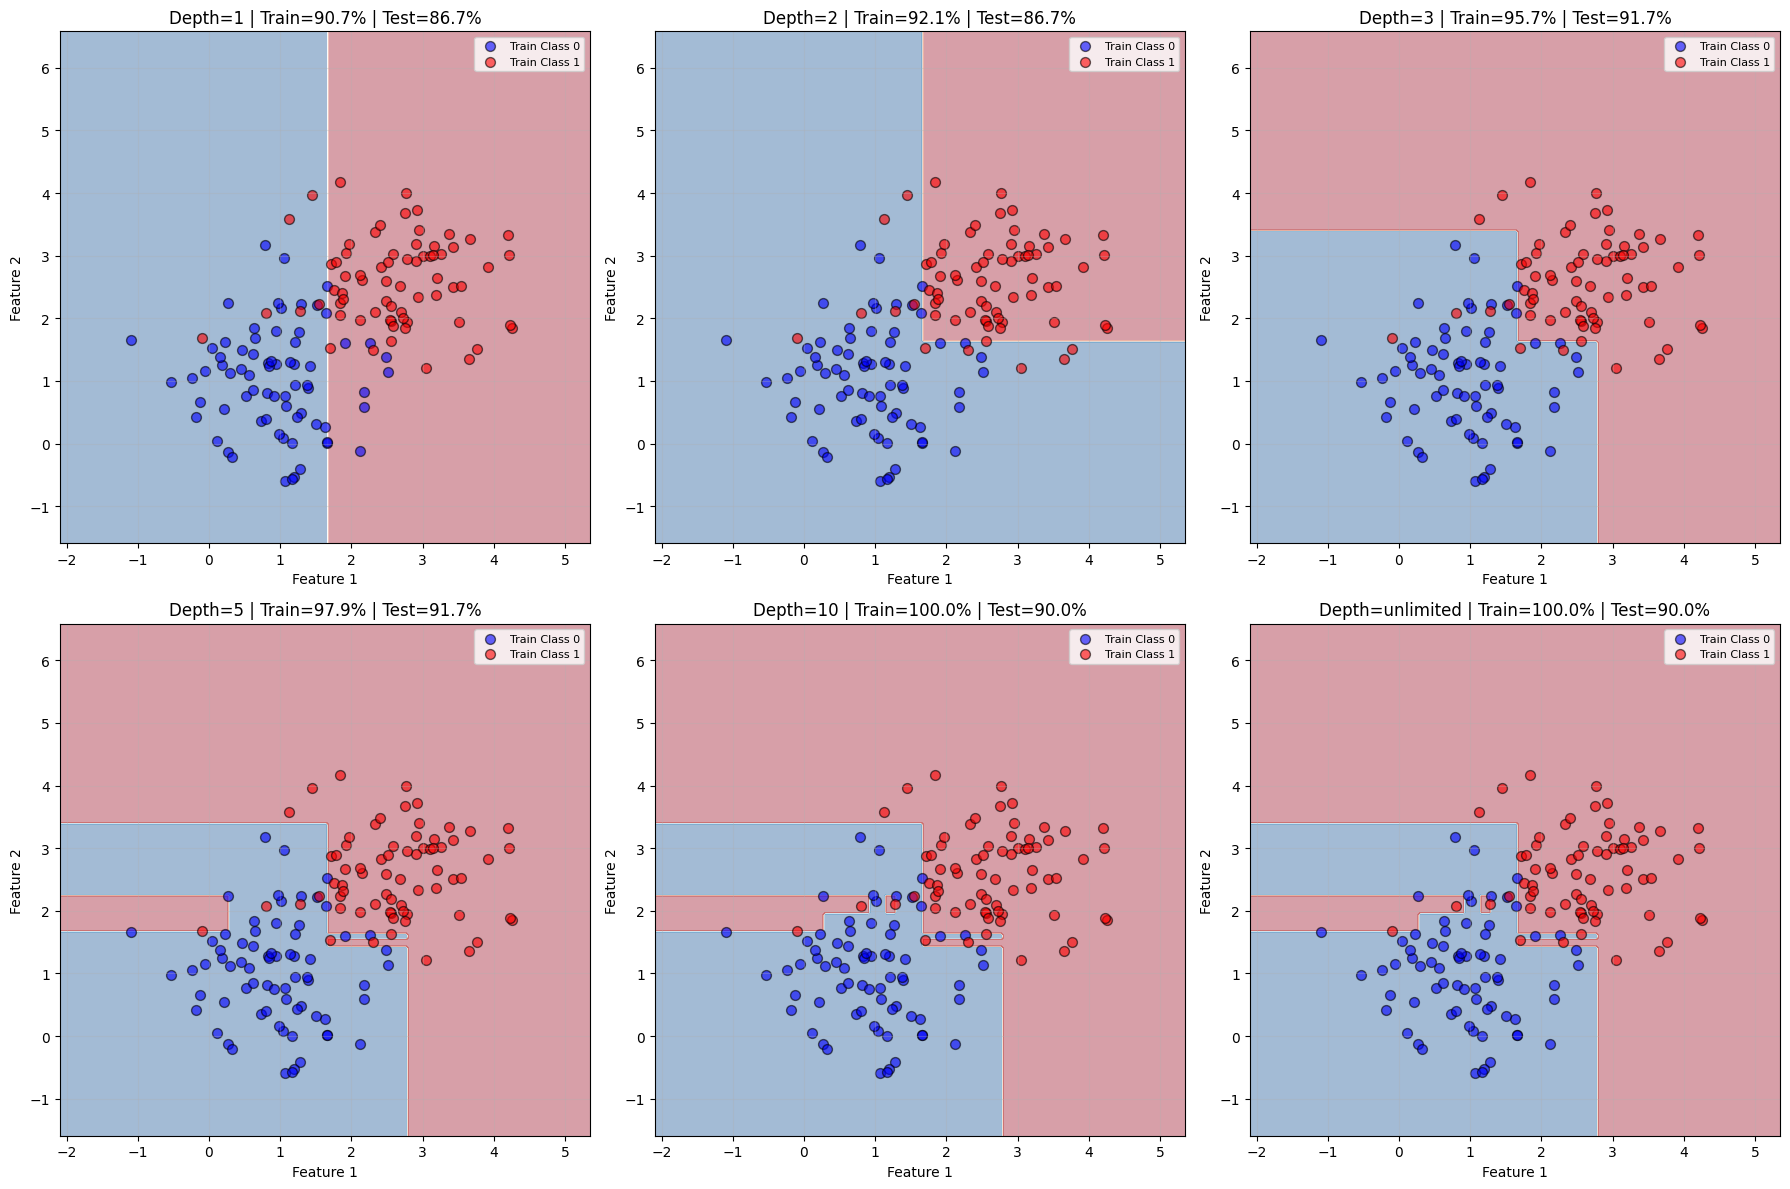

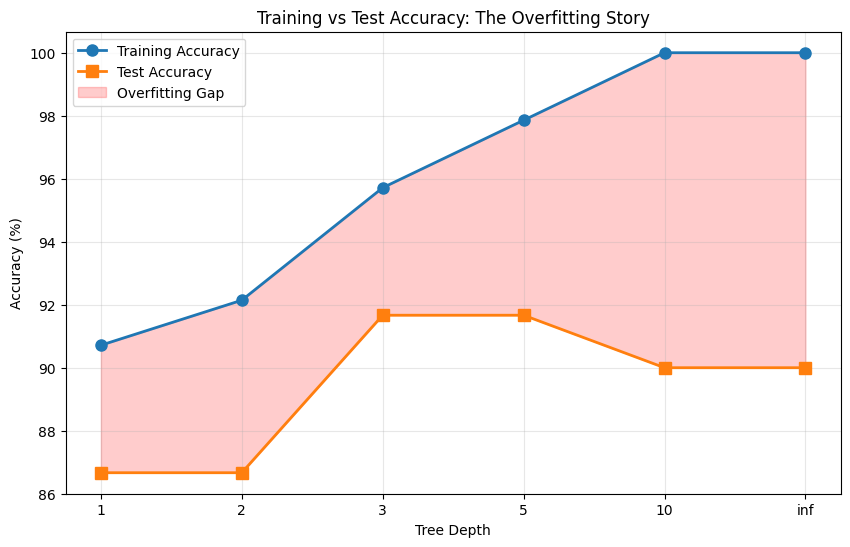


Key Observation:
As depth increases:
  Training accuracy goes UP   (memorizing training data)
  Test accuracy PEAKS then DOWN (overfitting to noise)
  The GAP between them WIDENS   (overfitting signature)

Optimal depth = where TEST accuracy is highest!


In [8]:
# ============================================================
# OVERFITTING: THE DANGER OF TREES THAT ARE TOO DEEP
# ============================================================
# So far our trees got 100% accuracy — that sounds great!
# But 100% on TRAINING data doesn't mean the model is good.
#
# THE PROBLEM: OVERFITTING
# A very deep tree can memorize every training example,
# including the random noise. It gets 100% train accuracy
# but fails badly on new, unseen data.
#
# ANALOGY:
# Imagine studying for an exam by memorizing the answers
# to every practice question EXACTLY.
# You'd ace the practice test, but fail the real exam
# because you memorized, not learned!
#
# THE SOLUTION: Train/Test Split
# - TRAINING set: used to build the tree
# - TEST set:     held out, never seen during training
#                 simulates "real world" new data
#
# A good model has SIMILAR train and test accuracy.
# A bad (overfit) model has HIGH train but LOW test accuracy.
#
# ASCII Diagram of overfitting vs. good fit:
#
#   Accuracy
#     ^
#  100|----[Train]----            <- Overfit: memorized training
#     |
#   85|         [Test]
#     |
#   90|----[Train]----[Test]----  <- Good fit: generalizes well
#     |
#     +---depth 1--depth 5--depth 10-->
# ============================================================

print("\n" + "=" * 60)
print("Better Dataset: Showing Depth Effect")
print("=" * 60)

np.random.seed(42)

# ============================================================
# STEP 1: CREATE OVERLAPPING CLUSTERS
# ============================================================
# Unlike before, these clusters are CLOSE TOGETHER and overlap.
# This means no single cut gives 100% accuracy —
# deeper trees are tempted to overfit the noise!
#
# Class 0: centered at (1.0, 1.0)   with spread = 0.8
# Class 1: centered at (2.5, 2.5)   with spread = 0.8
#
# They overlap in the middle -> some points are ambiguous!
# ============================================================

X_class0 = np.random.randn(100, 2) * 0.8 + np.array([1, 1])
y_class0 = np.zeros(100)

X_class1 = np.random.randn(100, 2) * 0.8 + np.array([2.5, 2.5])
y_class1 = np.ones(100)

# Combine and shuffle
X = np.vstack([X_class0, X_class1])
y = np.hstack([y_class0, y_class1])
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

# ============================================================
# STEP 2: TRAIN / TEST SPLIT
# ============================================================
# We split data into:
#   70% Training  -> tree sees this during fit()
#   30% Test      -> tree NEVER sees this; used only for eval
#
# train_test_split from sklearn handles this cleanly.
# random_state=42 makes the split reproducible.
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {len(X_train)} examples")
print(f"Test:     {len(X_test)} examples")

# ============================================================
# STEP 3: TRAIN TREES AT MANY DEPTHS
# ============================================================
# We test depths [1, 2, 3, 5, 10, unlimited].
#
# What to expect:
#   Depth 1:   Very simple, one cut -> low train AND test acc
#   Depth 2-3: Reasonable fit       -> good train AND test acc
#   Depth 10+: Memorises training   -> 100% train, LOW test acc
#
# The "sweet spot" is the depth where TEST accuracy peaks!
# ============================================================

depths = [1, 2, 3, 5, 10, None]  # None = unlimited depth

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # 2x3 grid -> flat list of 6 axes

# Lists to track accuracy at each depth for the summary plot
train_accs = []
test_accs = []

for idx, max_depth in enumerate(depths):

    # Train a fresh tree using ONLY training data
    tree = DecisionTree(max_depth=max_depth, criterion='entropy')
    tree.fit(X_train, y_train)

    # Evaluate on BOTH sets
    y_train_pred = tree.predict(X_train)
    y_test_pred  = tree.predict(X_test)

    # Accuracy = fraction of correct predictions
    train_acc = np.mean(y_train_pred == y_train) * 100
    test_acc  = np.mean(y_test_pred  == y_test)  * 100

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Print the train-test gap (key overfitting indicator!)
    label = max_depth if max_depth else 'unlimited'
    print(f"\nDepth = {label}:")
    print(f"  Train accuracy: {train_acc:.1f}%")
    print(f"  Test accuracy:  {test_acc:.1f}%")
    print(f"  Gap: {train_acc - test_acc:.1f}%  <- should be small!")

    # ---- Visualise decision boundary ----
    ax = axes[idx]

    # Dense grid to colour the background by predicted class
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))

    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu_r')

    # Only plot TRAINING points — these are what the tree learned from
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
               c='blue', s=50, edgecolors='black', alpha=0.6, label='Train Class 0')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
               c='red', s=50, edgecolors='black', alpha=0.6, label='Train Class 1')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Depth={label} | Train={train_acc:.1f}% | Test={test_acc:.1f}%')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 4: PLOT THE OVERFITTING CURVE
# ============================================================
# This is the most important plot — it shows the classic
# bias-variance tradeoff:
#
#   Accuracy
#     ^
#  100|  Train ......................
#     |                           .
#   90|         Test ----         .
#     |        /         \        .
#   80|       /           \       .
#     |      /             \......
#     +--1---2---3---5---10---inf-->
#               Depth
#
# Train accuracy keeps rising (tree memorizes more).
# Test accuracy rises, peaks, then falls (overfitting!).
# The RED shaded area between them = the overfitting gap.
#
# The depth where TEST accuracy peaks = optimal depth!
# ============================================================

plt.figure(figsize=(10, 6))
depth_labels = [str(d) if d else 'inf' for d in depths]
x_pos = range(len(depths))

# Plot both lines
plt.plot(x_pos, train_accs, 'o-', linewidth=2, markersize=8, label='Training Accuracy')
plt.plot(x_pos, test_accs,  's-', linewidth=2, markersize=8, label='Test Accuracy')

# Shade the gap between train and test (the overfitting zone)
plt.fill_between(x_pos, train_accs, test_accs,
                 alpha=0.2, color='red', label='Overfitting Gap')

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Test Accuracy: The Overfitting Story')
plt.xticks(x_pos, depth_labels)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("Key Observation:")
print("=" * 60)
print("As depth increases:")
print("  Training accuracy goes UP   (memorizing training data)")
print("  Test accuracy PEAKS then DOWN (overfitting to noise)")
print("  The GAP between them WIDENS   (overfitting signature)")
print("\nOptimal depth = where TEST accuracy is highest!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. ALWAYS evaluate on a held-out test set — never just training!
#
# 2. High train accuracy + low test accuracy = OVERFITTING
#    The model memorized instead of learning general patterns
#
# 3. Low train AND test accuracy = UNDERFITTING
#    The model is too simple to capture the pattern
#
# 4. The BIAS-VARIANCE TRADEOFF:
#    - Shallow tree (high bias, low variance):  underfits
#    - Deep tree   (low bias, high variance):   overfits
#    - Just right:                              generalizes!
#
# 5. Use a train/test split (or cross-validation) to find
#    the optimal depth for your specific dataset
# ============================================================


In [9]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
# After building a tree, a natural question is:
#   'Which features (columns) did the tree actually USE?
#    And how much did each one help?'
#
# This is called FEATURE IMPORTANCE.
#
# HOW WE MEASURE IT:
# Every time the tree splits on a feature, it reduces impurity
# by some amount. We CREDIT that feature for that reduction.
#
# Importance of feature F =
#   SUM over all nodes that split on F of:
#     (number of examples at that node) * (information gain)
#
# Why multiply by the number of examples?
#   A split near the root affects MANY examples -> big credit
#   A split at a leaf affects few examples       -> small credit
#
# At the end we NORMALISE so all importances add up to 1.0.
#
# ANALOGY:
#   Imagine 5 workers sorting mail.
#   Worker A sorts 80% of the pile each day.
#   Worker B sorts the remaining 20%.
#   Feature importance is like measuring how much of the
#   'sorting work' each worker (feature) did.
# ============================================================

print('\n' + '=' * 60)
print('FEATURE IMPORTANCE IMPLEMENTATION')
print('=' * 60)

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# We extend our DecisionTree class using INHERITANCE.
#
# WHAT IS INHERITANCE?
#   Think of it like a blueprint.
#   DecisionTree is the parent blueprint.
#   DecisionTreeWithImportance INHERITS everything from it
#   (all the same fit/predict/print_tree methods)
#   and then ADDS new feature-importance functionality on top.
#
#   class Child(Parent):  <- Child gets everything Parent has
# ============================================================

class DecisionTreeWithImportance(DecisionTree):
    """
    Decision Tree that also tracks feature importances.

    Inherits all functionality from DecisionTree and adds:
    - Accumulating weighted information gain per feature
    - Normalizing so importances sum to 1.0
    - Pretty-printing importances
    """

    def __init__(self, max_depth=None, min_samples_split=2, criterion='entropy'):
        # super().__init__(...) calls the PARENT class constructor
        # This sets up max_depth, min_samples_split, criterion, root
        # (everything DecisionTree already knows how to do)
        super().__init__(max_depth, min_samples_split, criterion)

        # New attributes specific to this subclass:
        self.n_features = None          # How many features the data has
        self.feature_importance_ = None # Will hold importances after fit()

    # ----------------------------------------------------------
    # FIT: Build tree AND accumulate importances
    # ----------------------------------------------------------
    def fit(self, X, y):
        """
        Build the tree and compute feature importances in one pass.
        """

        # STEP 1: Record how many features (columns) the data has
        self.n_features = X.shape[1]

        # STEP 2: Create a score counter for each feature, starting at 0
        # e.g. for 2 features: [0.0, 0.0]
        self.feature_importance_ = np.zeros(self.n_features)

        # STEP 3: Build the tree using the importance-tracking version
        # (same as _build_tree but adds scores at each split)
        self.root = self._build_tree_with_importance(X, y, depth=0)

        # STEP 4: Normalise so all importances sum to 1.0
        # This makes them easy to interpret as percentages
        total_importance = np.sum(self.feature_importance_)
        if total_importance > 0:
            self.feature_importance_ /= total_importance

        return self

    # ----------------------------------------------------------
    # _BUILD_TREE_WITH_IMPORTANCE: Recursive build + score tracking
    # ----------------------------------------------------------
    def _build_tree_with_importance(self, X, y, depth):
        """
        Same as _build_tree, but whenever we make a split we
        ADD a score to the feature that was chosen.

        Score added = (number of examples) * (information gain)
        This weights splits higher up the tree more heavily.
        """

        m, n = X.shape
        n_classes = len(np.unique(y))

        # ---- STOPPING CONDITIONS (same as before) ----

        # Pure node: all examples are the same class
        if n_classes == 1:
            return Node(value=y[0])

        # Max depth reached
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=self._most_common_class(y))

        # Too few examples to split
        if m < self.min_samples_split:
            return Node(value=self._most_common_class(y))

        # ---- FIND BEST SPLIT ----
        best_feature, best_threshold, best_gain = find_best_split(X, y, self.criterion)

        # No useful split found
        if best_gain == 0:
            return Node(value=self._most_common_class(y))

        # ---- CREDIT THE FEATURE THAT WAS CHOSEN ----
        # m * best_gain = weighted information gain
        # A root split (large m) on a useful feature (high gain)
        # gets a very large score. A deep leaf split gets a small score.
        self.feature_importance_[best_feature] += m * best_gain

        # ---- SPLIT DATA AND RECURSE ----
        left_mask  = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] >  best_threshold

        X_left,  y_left  = X[left_mask],  y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]

        left_subtree  = self._build_tree_with_importance(X_left,  y_left,  depth + 1)
        right_subtree = self._build_tree_with_importance(X_right, y_right, depth + 1)

        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )

    # ----------------------------------------------------------
    # GET_FEATURE_IMPORTANCE: Return the importance array
    # ----------------------------------------------------------
    def get_feature_importance(self):
        """
        Return the array of feature importances.
        Raises an error if fit() hasn't been called yet.
        """
        # Guard: make sure fit() was called first
        if self.feature_importance_ is None:
            raise ValueError('Must fit tree before getting importances')

        return self.feature_importance_

    # ----------------------------------------------------------
    # PRINT_FEATURE_IMPORTANCE: Human-readable summary
    # ----------------------------------------------------------
    def print_feature_importance(self, feature_names=None):
        """
        Print a sorted table of feature importances.

        Args:
            feature_names: list of names for each feature.
                           If None, uses 'Feature 0', 'Feature 1', etc.
        """
        importances = self.get_feature_importance()

        # Use generic names if none provided
        if feature_names is None:
            feature_names = [f'Feature {i}' for i in range(len(importances))]

        print('\nFeature Importances:')
        print('=' * 50)

        # Sort from most important to least important
        # np.argsort returns indices that would sort the array
        # [::-1] reverses it so highest comes first
        indices = np.argsort(importances)[::-1]

        for i in indices:
            bar = '#' * int(importances[i] * 30)  # Visual bar
            print(f'{feature_names[i]:35s}: {importances[i]:.4f} ({importances[i]*100:.1f}%) {bar}')

        print('=' * 50)
        print(f"{'Total':35s}: {np.sum(importances):.4f} (should be 1.0)")


print('Feature Importance class ready!')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. Feature importance = how much each feature reduced impurity
#
# 2. Score = sum of (n_examples * info_gain) across all splits
#    on that feature.  Splits near the root count MORE.
#
# 3. Scores are normalised so they sum to 1.0
#    -> easy to read as percentages
#
# 4. High importance: feature was used a lot and helped a lot
#    Low/zero importance: feature was rarely used or useless
#
# 5. This is super useful in real projects!
#    You can DROP features with near-zero importance to make
#    your model faster and simpler.
# ============================================================



FEATURE IMPORTANCE IMPLEMENTATION
Feature Importance class ready!



Testing Feature Importance
Dataset: 200 examples, 2 features

Depth = 1
Training Accuracy: 89.5%

Feature Importances:
Feature 1 (x-axis)                 : 1.0000 (100.0%) ##############################
Feature 2 (y-axis)                 : 0.0000 (0.0%) 
Total                              : 1.0000 (should be 1.0)

Depth = 2
Training Accuracy: 90.0%

Feature Importances:
Feature 1 (x-axis)                 : 0.6992 (69.9%) ####################
Feature 2 (y-axis)                 : 0.3008 (30.1%) #########
Total                              : 1.0000 (should be 1.0)

Depth = 3
Training Accuracy: 95.0%

Feature Importances:
Feature 1 (x-axis)                 : 0.6915 (69.1%) ####################
Feature 2 (y-axis)                 : 0.3085 (30.9%) #########
Total                              : 1.0000 (should be 1.0)

Depth = 5
Training Accuracy: 97.0%

Feature Importances:
Feature 1 (x-axis)                 : 0.6629 (66.3%) ###################
Feature 2 (y-axis)                 : 0.3371 (33.

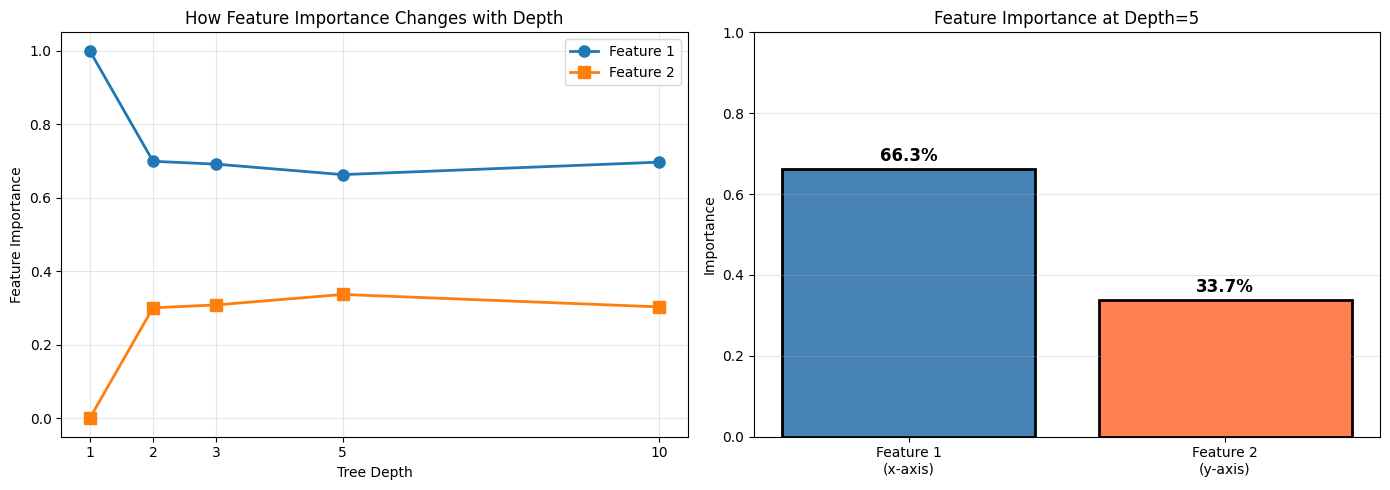


Feature Importance Analysis Complete!


In [10]:
# ============================================================
# TESTING FEATURE IMPORTANCE ON A 2-FEATURE DATASET
# ============================================================
# We use the same overlapping 2-class dataset from before.
# With only 2 features (x-axis and y-axis), it's easy to
# understand and verify which one matters more.
#
# WHAT TO EXPECT:
# Both features contribute, but Feature 1 (x-axis) tends
# to dominate because the clusters are more separated
# horizontally than vertically.
#
# We also test how DEPTH affects importance:
# - Shallow tree: only uses the single best feature
# - Deeper tree:  uses more features for fine-grained splits
# ============================================================

print('\n' + '=' * 60)
print('Testing Feature Importance')
print('=' * 60)

# ============================================================
# STEP 1: Recreate the overlapping 2-class dataset
# ============================================================
# Same as the overfitting cell — two clusters that overlap
# in the middle, so no single cut is perfect.
# ============================================================

np.random.seed(42)

# Class 0: centered at (1.0, 1.0) with spread 0.8
X_class0 = np.random.randn(100, 2) * 0.8 + np.array([1, 1])
y_class0 = np.zeros(100)

# Class 1: centered at (2.5, 2.5) with spread 0.8
X_class1 = np.random.randn(100, 2) * 0.8 + np.array([2.5, 2.5])
y_class1 = np.ones(100)

# Combine and shuffle
X = np.vstack([X_class0, X_class1])
y = np.hstack([y_class0, y_class1])
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

print(f'Dataset: {len(X)} examples, {X.shape[1]} features')

# ============================================================
# STEP 2: Train trees at different depths and show importances
# ============================================================
# Notice how feature importances SHIFT as depth increases:
# - Depth 1: only one feature used -> 100% importance on that feature
# - Deeper:  both features used -> importance spreads out
# ============================================================

depths = [1, 2, 3, 5, None]

for depth in depths:
    print(f"\n{'='*60}")
    print(f"Depth = {depth if depth else 'unlimited'}")
    print(f"{'='*60}")

    # Train the importance-tracking tree
    tree = DecisionTreeWithImportance(max_depth=depth, criterion='entropy')
    tree.fit(X, y)

    # Accuracy on training data
    y_pred = tree.predict(X)
    accuracy = np.mean(y_pred == y) * 100
    print(f'Training Accuracy: {accuracy:.1f}%')

    # Print the feature importance table
    # We give descriptive names to make the output readable
    tree.print_feature_importance(feature_names=['Feature 1 (x-axis)', 'Feature 2 (y-axis)'])

# ============================================================
# STEP 3: Plot how importances change with depth
# ============================================================
# Two plots side by side:
#   Left:  importance of each feature across depths (line plot)
#   Right: bar chart of importances at depth=5
# ============================================================

print('\n' + '=' * 60)
print('Visualizing Feature Importance vs Depth')
print('=' * 60)

# Collect importances at each depth
depths_plot = [1, 2, 3, 5, 10]
importances_f1 = []   # Importance of Feature 1 at each depth
importances_f2 = []   # Importance of Feature 2 at each depth

for depth in depths_plot:
    tree = DecisionTreeWithImportance(max_depth=depth)
    tree.fit(X, y)
    imp = tree.get_feature_importance()
    importances_f1.append(imp[0])   # First feature's importance
    importances_f2.append(imp[1])   # Second feature's importance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left plot: importances vs depth ----
# Shows how the importance balance shifts as the tree grows deeper
ax1.plot(depths_plot, importances_f1, 'o-', linewidth=2, markersize=8, label='Feature 1')
ax1.plot(depths_plot, importances_f2, 's-', linewidth=2, markersize=8, label='Feature 2')
ax1.set_xlabel('Tree Depth')
ax1.set_ylabel('Feature Importance')
ax1.set_title('How Feature Importance Changes with Depth')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(depths_plot)

# ---- Right plot: bar chart at depth=5 ----
# A simple snapshot: which feature matters more at depth 5?
tree_final = DecisionTreeWithImportance(max_depth=5)
tree_final.fit(X, y)
importances_final = tree_final.get_feature_importance()

ax2.bar(['Feature 1\n(x-axis)', 'Feature 2\n(y-axis)'],
        importances_final,
        color=['steelblue', 'coral'], edgecolor='black', linewidth=2)
ax2.set_ylabel('Importance')
ax2.set_title('Feature Importance at Depth=5')
ax2.set_ylim([0, 1])
ax2.grid(True, axis='y', alpha=0.3)

# Add percentage labels on each bar so they're easy to read
for i, v in enumerate(importances_final):
    ax2.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nFeature Importance Analysis Complete!')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. At depth=1, only ONE feature is ever used
#    -> it gets 100% of the importance!
#
# 2. As depth increases, BOTH features get used
#    -> importance spreads across features
#
# 3. The feature that separates classes better gets higher score
#
# 4. The bar chart is an easy way to see which features matter
#
# 5. Features near 0% importance are candidates for removal!
# ============================================================



Feature Importance with Multiple Features
Dataset: 200 examples, 5 features
Class 0: 100 examples
Class 1: 100 examples

Training Accuracy: 100.0%

Feature Importances:
Feature 1 (strong signal)          : 1.0000 (100.0%) ##############################
Feature 5 (weak signal)            : 0.0000 (0.0%) 
Feature 4 (random noise)           : 0.0000 (0.0%) 
Feature 3 (redundant with f1)      : 0.0000 (0.0%) 
Feature 2 (moderate signal)        : 0.0000 (0.0%) 
Total                              : 1.0000 (should be 1.0)


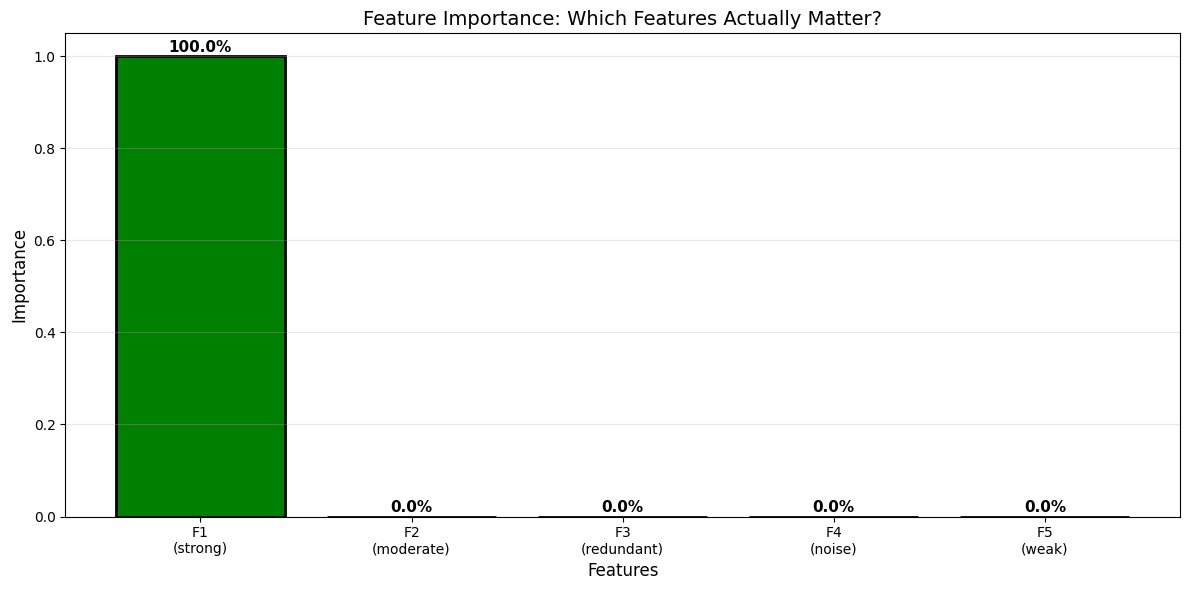


Key Observations:
* Feature 1 (strong signal)    -> HIGH importance  (defines the target!)
* Feature 2 (moderate signal)  -> MEDIUM importance
* Feature 3 (redundant)        -> LOW importance   (f1 already captured it)
* Feature 4 (random noise)     -> NEAR ZERO        (useless — as expected!)
* Feature 5 (weak signal)      -> SMALL importance


In [11]:
# ============================================================
# FEATURE IMPORTANCE WITH 5 FEATURES
# ============================================================
# Now let's test with MORE features — some useful, some useless.
#
# We DESIGN the dataset so we already KNOW the answer:
#
# Feature 1: STRONG SIGNAL   — target directly depends on it
# Feature 2: MODERATE SIGNAL — adds some refinement
# Feature 3: REDUNDANT       — basically a copy of Feature 1
# Feature 4: PURE NOISE      — completely random, no signal!
# Feature 5: WEAK SIGNAL     — small correlation with target
#
# WHAT WE EXPECT THE TREE TO DISCOVER:
#   Feature 1 >> Feature 2 > Feature 5 >> Feature 3 > Feature 4 ≈ 0
#
# This is how feature importance is used in real ML projects:
#   1. Train a tree
#   2. Check importances
#   3. Drop the near-zero features
#   4. Retrain with fewer features -> faster, often same accuracy!
# ============================================================

print('\n' + '=' * 60)
print('Feature Importance with Multiple Features')
print('=' * 60)

np.random.seed(42)
m = 200  # Total number of examples

# ============================================================
# STEP 1: DESIGN FEATURES WITH KNOWN IMPORTANCE
# ============================================================

# Feature 1: Strong signal
# The TARGET (y) is directly defined by this feature.
# If f1 > 0 -> class 1, else -> class 0.
# So knowing f1 almost perfectly predicts the label!
f1 = np.random.randn(m)
y_multi = (f1 > 0).astype(int)  # label = 1 if f1 positive, else 0

# Feature 2: Moderate signal
# Shifted slightly toward class 1 region but with noise.
# y_multi * 0.5 means class-1 examples get +0.5 on average.
f2 = np.random.randn(m) + y_multi * 0.5

# Feature 3: Redundant (almost a copy of f1)
# f1 + tiny noise. Contains the same information as f1,
# but since f1 is already used first, f3 adds almost nothing.
f3 = f1 + np.random.randn(m) * 0.1

# Feature 4: Pure random noise
# Completely unrelated to the label.
# Expected importance: ~0%
f4 = np.random.randn(m)

# Feature 5: Weak signal
# Smaller shift (0.3) than f2 (0.5) -> less useful.
f5 = np.random.randn(m) + y_multi * 0.3

# Combine all 5 features into one matrix
# np.column_stack puts each 1D array as a column
# Result shape: (200, 5)
X_multi = np.column_stack([f1, f2, f3, f4, f5])

print(f'Dataset: {m} examples, {X_multi.shape[1]} features')
print(f'Class 0: {np.sum(y_multi==0)} examples')
print(f'Class 1: {np.sum(y_multi==1)} examples')

# ============================================================
# STEP 2: TRAIN THE TREE AND GET IMPORTANCES
# ============================================================

tree_multi = DecisionTreeWithImportance(max_depth=5, criterion='entropy')
tree_multi.fit(X_multi, y_multi)

# Accuracy on training data
y_pred_multi = tree_multi.predict(X_multi)
accuracy = np.mean(y_pred_multi == y_multi) * 100
print(f'\nTraining Accuracy: {accuracy:.1f}%')

# ============================================================
# STEP 3: PRINT IMPORTANCES
# ============================================================
# Descriptive names make the output much easier to interpret
# ============================================================

feature_names = [
    'Feature 1 (strong signal)',
    'Feature 2 (moderate signal)',
    'Feature 3 (redundant with f1)',
    'Feature 4 (random noise)',
    'Feature 5 (weak signal)'
]

tree_multi.print_feature_importance(feature_names)

# ============================================================
# STEP 4: BAR CHART VISUALISATION
# ============================================================
# A visual makes the ranking immediately obvious.
# We use different colors to visually group features by type.
# ============================================================

importances = tree_multi.get_feature_importance()

plt.figure(figsize=(12, 6))

# Color each bar differently so they're easy to distinguish
colors = ['green', 'steelblue', 'orange', 'red', 'purple']
bars = plt.bar(range(len(importances)), importances,
               color=colors, edgecolor='black', linewidth=2)

plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Feature Importance: Which Features Actually Matter?', fontsize=14)
plt.xticks(range(len(importances)),
           ['F1\n(strong)', 'F2\n(moderate)', 'F3\n(redundant)', 'F4\n(noise)', 'F5\n(weak)'])
plt.grid(True, axis='y', alpha=0.3)

# Print percentage on top of each bar
for i, v in enumerate(importances):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print('\n' + '=' * 60)
print('Key Observations:')
print('=' * 60)
print('* Feature 1 (strong signal)    -> HIGH importance  (defines the target!)')
print('* Feature 2 (moderate signal)  -> MEDIUM importance')
print('* Feature 3 (redundant)        -> LOW importance   (f1 already captured it)')
print('* Feature 4 (random noise)     -> NEAR ZERO        (useless — as expected!)')
print('* Feature 5 (weak signal)      -> SMALL importance')

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. The tree CORRECTLY identifies that Feature 1 matters most
#    even though we never told it that — it learned from data!
#
# 2. REDUNDANT features get LOW importance:
#    Feature 3 duplicates Feature 1, so once f1 is used,
#    f3 adds nothing new and is rarely selected.
#
# 3. NOISE features get NEAR-ZERO importance:
#    Random data gives no information gain -> never selected!
#
# 4. PRACTICAL USE CASE:
#    In a real dataset with 100 features, you can:
#      a) Train a tree
#      b) Rank features by importance
#      c) Keep only the top 10-20 features
#      d) Retrain on just those -> same accuracy, much faster!
#    This is called FEATURE SELECTION.
# ============================================================


In [12]:
print("=" * 60)
print("DECISION TREE WITH ALL HYPERPARAMETERS")
print("=" * 60)

import numpy as np
import matplotlib.pyplot as plt

class DecisionTreePruned(DecisionTree):
    """
    Decision Tree with full hyperparameter control
    
    Hyperparameters:
    - max_depth: Maximum tree depth
    - min_samples_split: Minimum samples to split
    - min_samples_leaf: Minimum samples in leaf
    - max_features: Features to consider per split
    - min_impurity_decrease: Minimum IG to split
    """
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=None, min_impurity_decrease=0.0, criterion='entropy'):
        
        """
        Initialize tree with hyperparameters
        
        Args:
            max_depth: Max depth (None = unlimited)
            min_samples_split: Min samples to attempt split
            min_samples_leaf: Min samples in each leaf
            max_features: Max features per split (None = all)
            min_impurity_decrease: Min IG required
            criterion: 'entropy' or 'gini'
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.min_impurity_decrease = min_impurity_decrease
        self.criterion = criterion
        self.root = None
        self.n_features = None
        self.feature_importances_ = None

    def fit(self, X, y):
        """Build tree with all hyperparameters"""
        self.n_features = X.shape[1]
        self.feature_importances_ = np.zeros(self.n_features)
        
        # Build tree
        self.root = self._build_tree(X, y, depth=0)
        
        # Normalize importances
        if np.sum(self.feature_importances_) > 0:
            self.feature_importances_ /= np.sum(self.feature_importances_)
        
        return self
    
    def _build_tree(self, X, y, depth):
        """
        Recursively build tree with ALL stopping criteria
        """
        m, n = X.shape
        n_classes = len(np.unique(y))
        
        # ============================================
        # STOPPING CRITERIA (Pre-Pruning)
        # ============================================
        
        # Stop 1: Pure node
        if n_classes == 1:
            return Node(value=y[0])
        
        # Stop 2: Max depth reached
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(value=self._most_common_class(y))
        
                
        # Stop 3: Not enough samples to split
        if m < self.min_samples_split:
            return Node(value=self._most_common_class(y))
        

        # ============================================
        # FIND BEST SPLIT (with max_features)
        # ============================================
        
        # Determine features to consider
        if self.max_features is None:
            features_to_try = range(n)
        else:
            # Randomly select max_features
            n_features_to_try = min(self.max_features, n)
            features_to_try = np.random.choice(n, n_features_to_try, replace=False)
        
        # Find best split among selected features
        best_gain = -1
        best_feature = None
        best_threshold = None
        best_left_mask = None
        best_right_mask = None
        
        for feature_idx in features_to_try:
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)
            
            # Try splits between adjacent values
            for i in range(len(unique_values) - 1):
                threshold = (unique_values[i] + unique_values[i + 1]) / 2
                
                # Split data
                left_mask = feature_values <= threshold
                right_mask = feature_values > threshold
                
                # Skip if either side empty
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                # Stop 4: Check min_samples_leaf BEFORE committing
                if (np.sum(left_mask) < self.min_samples_leaf or 
                    np.sum(right_mask) < self.min_samples_leaf):
                    continue
                
                # Compute information gain
                left_y = y[left_mask]
                right_y = y[right_mask]
                gain = information_gain(y, left_y, right_y, self.criterion)
                
                # Stop 5: Check min_impurity_decrease
                if gain < self.min_impurity_decrease:
                    continue
                
                # Update best split
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
                    best_left_mask = left_mask
                    best_right_mask = right_mask
        
        # Stop 6: No valid split found
        if best_gain == 0 or best_feature is None:
            return Node(value=self._most_common_class(y))
        
        # ============================================
        # SPLIT AND RECURSE
        # ============================================
        
        # Record importance
        self.feature_importances_[best_feature] += m * best_gain
        
        # Split data
        X_left, y_left = X[best_left_mask], y[best_left_mask]
        X_right, y_right = X[best_right_mask], y[best_right_mask]
        
        # Build subtrees
        left_subtree = self._build_tree(X_left, y_left, depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)
        
        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )
    
    def _most_common_class(self, y):
        """Return most common class"""
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]
    
    def predict(self, X):
        """Make predictions"""
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        """Traverse tree for single example"""
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

print("✓ Full Hyperparameter Implementation Complete!")

DECISION TREE WITH ALL HYPERPARAMETERS
✓ Full Hyperparameter Implementation Complete!



Testing Different Hyperparameter Configurations
Training: 140 samples
Test:     60 samples

No Constraints (Overfit Risk)
Parameters: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
Training accuracy: 100.0%
Test accuracy:     90.0%
Gap:               10.0%

Moderate Pruning
Parameters: {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5}
Training accuracy: 93.6%
Test accuracy:     91.7%
Gap:               1.9%
Good balance!

Heavy Pruning
Parameters: {'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 10}
Training accuracy: 92.1%
Test accuracy:     86.7%
Gap:               5.5%

Impurity-Based Pruning
Parameters: {'max_depth': 10, 'min_impurity_decrease': 0.01}
Training accuracy: 100.0%
Test accuracy:     90.0%
Gap:               10.0%


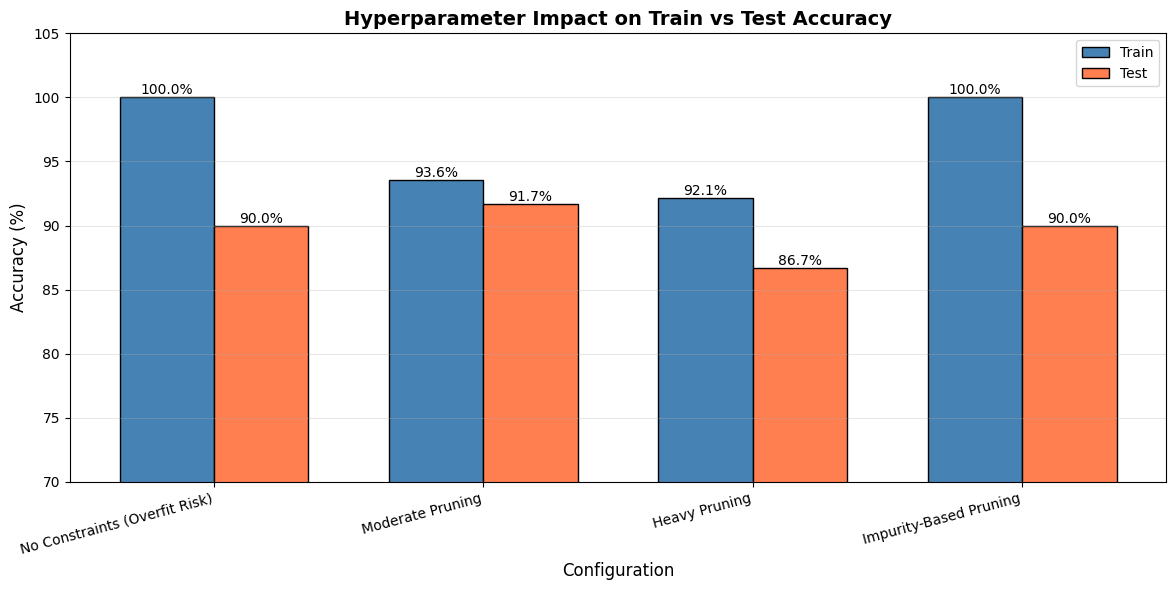


Hyperparameter Testing Complete!


In [13]:
# ============================================================
# TESTING DIFFERENT HYPERPARAMETER CONFIGURATIONS
# ============================================================
# A HYPERPARAMETER is a setting you choose BEFORE training.
# (Parameters like theta are learned FROM data; hyperparameters
#  are set BY YOU to control how learning happens.)
#
# For Decision Trees the key hyperparameters are:
#
#   max_depth          How many levels deep the tree can grow.
#                      Shallow = simple, Deep = complex (overfit risk)
#
#   min_samples_split  Minimum examples needed to attempt a split.
#                      Higher = more conservative tree (fewer splits)
#
#   min_samples_leaf   Minimum examples that must end up in a leaf.
#                      Higher = each final region covers more data
#
#   min_impurity_decrease
#                      Only split if the gain is >= this threshold.
#                      Higher = only make "worth-it" splits
#
# We test 4 preset configurations and compare their train vs test
# accuracy to find a good balance (not overfit, not underfit).
#
# KEY METRIC: the GAP between train and test accuracy
#   Gap > 5%  -> Overfitting  (memorising training data)
#   Gap < -5% -> Underfitting (model too simple)
#   Gap ~ 0%  -> Just right!
# ============================================================

print("\n" + "=" * 60)
print("Testing Different Hyperparameter Configurations")
print("=" * 60)

# ============================================================
# STEP 1: GENERATE THE OVERLAPPING DATASET
# ============================================================

np.random.seed(42)
X_class0 = np.random.randn(100, 2) * 0.8 + np.array([1, 1])
y_class0 = np.zeros(100)
X_class1 = np.random.randn(100, 2) * 0.8 + np.array([2.5, 2.5])
y_class1 = np.ones(100)

# Combine and shuffle
X = np.vstack([X_class0, X_class1])
y = np.hstack([y_class0, y_class1])
indices = np.random.permutation(len(y))
X = X[indices]
y = y[indices]

# ============================================================
# STEP 2: TRAIN / TEST SPLIT
# ============================================================
# 70% training, 30% test.
# The test set is NEVER used during training — only for final eval.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training: {len(X_train)} samples")
print(f"Test:     {len(X_test)} samples")

# ============================================================
# STEP 3: DEFINE 4 CONFIGURATIONS TO COMPARE
# ============================================================
# Each dict has a human-readable name and a set of hyperparameters.
# This makes it easy to loop over and test all 4 automatically.

configs = [
    {
        'name': 'No Constraints (Overfit Risk)',
        'params': {
            'max_depth': None,        # Unlimited depth — can memorise!
            'min_samples_split': 2,   # Split even with just 2 examples
            'min_samples_leaf': 1     # Leaves can have just 1 example
        }
    },
    {
        'name': 'Moderate Pruning',
        'params': {
            'max_depth': 5,           # At most 5 levels deep
            'min_samples_split': 10,  # Need 10+ to attempt a split
            'min_samples_leaf': 5     # Each leaf must have 5+ examples
        }
    },
    {
        'name': 'Heavy Pruning',
        'params': {
            'max_depth': 3,           # Very shallow tree
            'min_samples_split': 20,  # Need 20+ to split (conservative)
            'min_samples_leaf': 10    # Large leaves — simple model
        }
    },
    {
        'name': 'Impurity-Based Pruning',
        'params': {
            'max_depth': 10,
            'min_impurity_decrease': 0.01  # Only split if gain >= 0.01
        }
    }
]

# ============================================================
# STEP 4: TRAIN EACH CONFIGURATION AND MEASURE RESULTS
# ============================================================

results = []  # Store results so we can plot them later

for config in configs:
    print(f"\n{'='*60}")
    print(f"{config['name']}")
    print(f"{'='*60}")
    print(f"Parameters: {config['params']}")

    # ** unpacks the dict as keyword arguments
    # e.g. {'max_depth': 5} -> max_depth=5
    tree = DecisionTreePruned(**config['params'])
    tree.fit(X_train, y_train)

    # Predict on BOTH sets
    y_train_pred = tree.predict(X_train)
    y_test_pred  = tree.predict(X_test)

    train_acc = np.mean(y_train_pred == y_train) * 100
    test_acc  = np.mean(y_test_pred  == y_test)  * 100
    gap = train_acc - test_acc  # Positive = overfitting

    print(f"Training accuracy: {train_acc:.1f}%")
    print(f"Test accuracy:     {test_acc:.1f}%")
    print(f"Gap:               {gap:.1f}%")

    # Diagnose the result
    if gap > 5:
        print("WARNING: Large gap -> overfitting!")
    elif gap < -5:
        print("WARNING: Negative gap -> underfitting!")
    else:
        print("Good balance!")

    results.append({
        'name': config['name'],
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'gap':       gap
    })

# ============================================================
# STEP 5: GROUPED BAR CHART — VISUAL COMPARISON
# ============================================================
# Grouped bars make it easy to spot which configs overfit
# (big blue bar, small coral bar) vs underfit (both small).

names      = [r['name']      for r in results]
train_accs = [r['train_acc'] for r in results]
test_accs  = [r['test_acc']  for r in results]

fig, ax = plt.subplots(figsize=(12, 6))
x     = np.arange(len(names))
width = 0.35

# Two bars per group: training (blue) and test (coral)
bars1 = ax.bar(x - width/2, train_accs, width, label='Train', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test',  color='coral',     edgecolor='black')

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Hyperparameter Impact on Train vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim([70, 105])

# Add accuracy labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nHyperparameter Testing Complete!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. 'No Constraints' -> probably overfits (large train-test gap)
#
# 2. 'Heavy Pruning'  -> might underfit (both accuracies low)
#
# 3. The sweet spot is somewhere in the middle
#
# 4. min_samples_split and min_samples_leaf act as REGULARISATION
#    They prevent the tree from over-committing to small clusters
#
# 5. min_impurity_decrease is an alternative: only split when the
#    gain is large enough to be "worth it"
# ============================================================



SYSTEMATIC HYPERPARAMETER TUNING

Method 1: Manual Grid Search with Cross-Validation
Hyperparameter Grid:
  max_depth: [3, 5, 7, 10]
  min_samples_split: [2, 10, 20]
  min_samples_leaf: [1, 5, 10]

Total combinations: 36

Searching for best hyperparameters...
------------------------------------------------------------
depth=3, split= 2, leaf= 1 → CV Score: 0.9071 (±0.0484)
depth=3, split= 2, leaf= 5 → CV Score: 0.9000 (±0.0571)
depth=3, split= 2, leaf=10 → CV Score: 0.9000 (±0.0571)
depth=3, split=10, leaf= 1 → CV Score: 0.9143 (±0.0484)
depth=3, split=10, leaf= 5 → CV Score: 0.9000 (±0.0571)
depth=3, split=10, leaf=10 → CV Score: 0.9000 (±0.0571)
depth=3, split=20, leaf= 1 → CV Score: 0.9143 (±0.0484)
depth=3, split=20, leaf= 5 → CV Score: 0.9143 (±0.0484)
depth=3, split=20, leaf=10 → CV Score: 0.9000 (±0.0571)
depth=5, split= 2, leaf= 1 → CV Score: 0.8929 (±0.0452)
depth=5, split= 2, leaf= 5 → CV Score: 0.9000 (±0.0571)
depth=5, split= 2, leaf=10 → CV Score: 0.9000 (±0.0571)
depth=

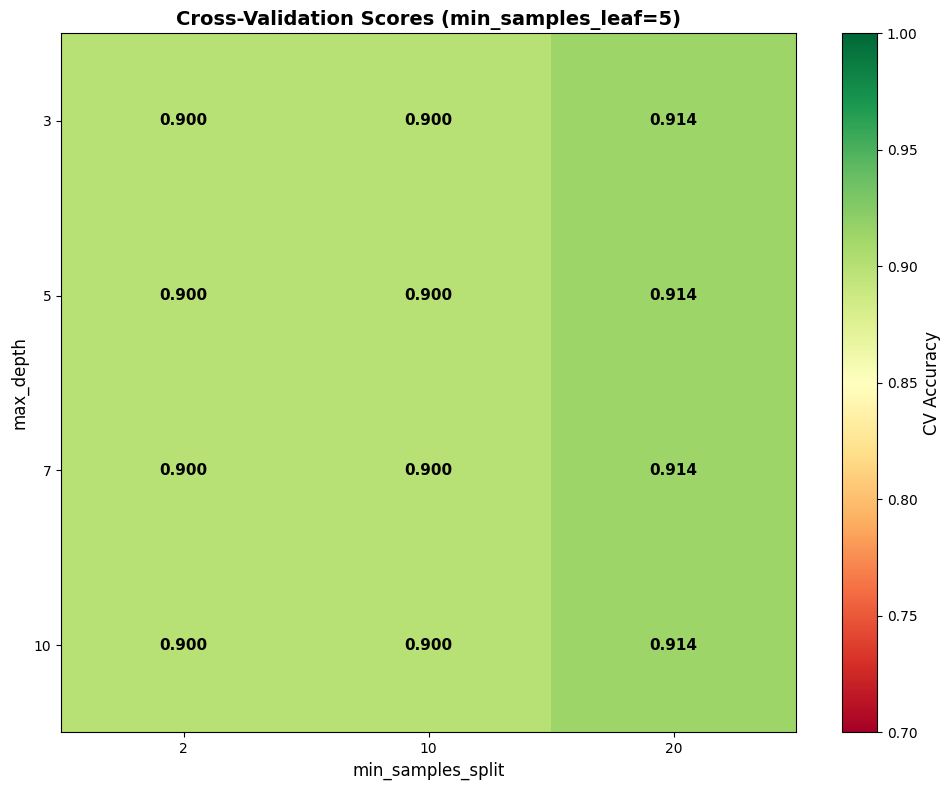

✓ Grid Search Complete!


In [14]:
print("\n" + "=" * 60)
print("SYSTEMATIC HYPERPARAMETER TUNING")
print("=" * 60)

from sklearn.model_selection import cross_val_score, GridSearchCV
import itertools

# ============================================
# METHOD 1: MANUAL GRID SEARCH WITH K-FOLD CV
# ============================================

print("\nMethod 1: Manual Grid Search with Cross-Validation")
print("=" * 60)

def cross_validate_tree(X, y, params, k=5):
    """
    K-fold cross-validation for decision tree
    
    Returns mean and std of validation accuracy
    """
    m = len(X)
    fold_size = m // k
    scores = []
    
    for fold in range(k):
        # Split into train and validation
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size
        
        X_val = X[val_start:val_end]
        y_val = y[val_start:val_end]
        X_train_cv = np.vstack([X[:val_start], X[val_end:]])
        y_train_cv = np.hstack([y[:val_start], y[val_end:]])
        
        # Train tree
        tree = DecisionTreePruned(**params)
        tree.fit(X_train_cv, y_train_cv)
        
        # Evaluate on validation fold
        y_val_pred = tree.predict(X_val)
        accuracy = np.mean(y_val_pred == y_val)
        scores.append(accuracy)
    
    return np.mean(scores), np.std(scores)

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

print("Hyperparameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])}")

# Grid search
print("\nSearching for best hyperparameters...")
print("-" * 60)

best_score = 0
best_params = None
all_results = []

# Try all combinations
for max_depth in param_grid['max_depth']:
    for min_samples_split in param_grid['min_samples_split']:
        for min_samples_leaf in param_grid['min_samples_leaf']:
            params = {
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf
            }
            
            # Cross-validate
            mean_score, std_score = cross_validate_tree(X_train, y_train, params, k=5)
            
            all_results.append({
                'params': params.copy(),
                'mean_score': mean_score,
                'std_score': std_score
            })
            
            # Update best
            if mean_score > best_score:
                best_score = mean_score
                best_params = params.copy()
            
            print(f"depth={max_depth}, split={min_samples_split:2d}, leaf={min_samples_leaf:2d} → "
                  f"CV Score: {mean_score:.4f} (±{std_score:.4f})")

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)
print(f"Parameters: {best_params}")
print(f"CV Score: {best_score:.4f}")

# Train final model with best parameters
tree_best = DecisionTreePruned(**best_params)
tree_best.fit(X_train, y_train)

# Evaluate on test set (only once!)
y_test_pred_best = tree_best.predict(X_test)
test_acc_best = np.mean(y_test_pred_best == y_test) * 100

print(f"Test Accuracy: {test_acc_best:.1f}%")

# ============================================
# VISUALIZE: HEATMAP OF RESULTS
# ============================================

print("\n" + "=" * 60)
print("Visualizing Hyperparameter Search Results")
print("=" * 60)

# Create heatmap for max_depth vs min_samples_split (fixing min_samples_leaf=5)
fixed_leaf = 5
depths = param_grid['max_depth']
splits = param_grid['min_samples_split']

scores_matrix = np.zeros((len(depths), len(splits)))

for i, depth in enumerate(depths):
    for j, split in enumerate(splits):
        # Find score for this combination
        for result in all_results:
            p = result['params']
            if (p['max_depth'] == depth and 
                p['min_samples_split'] == split and 
                p['min_samples_leaf'] == fixed_leaf):
                scores_matrix[i, j] = result['mean_score']
                break

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(scores_matrix, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.0)

# Labels
ax.set_xticks(range(len(splits)))
ax.set_yticks(range(len(depths)))
ax.set_xticklabels(splits)
ax.set_yticklabels(depths)
ax.set_xlabel('min_samples_split', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
ax.set_title(f'Cross-Validation Scores (min_samples_leaf={fixed_leaf})', 
             fontsize=14, fontweight='bold')

# Add score text
for i in range(len(depths)):
    for j in range(len(splits)):
        text = ax.text(j, i, f'{scores_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=11, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('CV Accuracy', fontsize=12)

plt.tight_layout()
plt.show()

print("✓ Grid Search Complete!")


LEARNING CURVES: Diagnosing Bias vs Variance

Plotting: No Pruning (Overfitting)


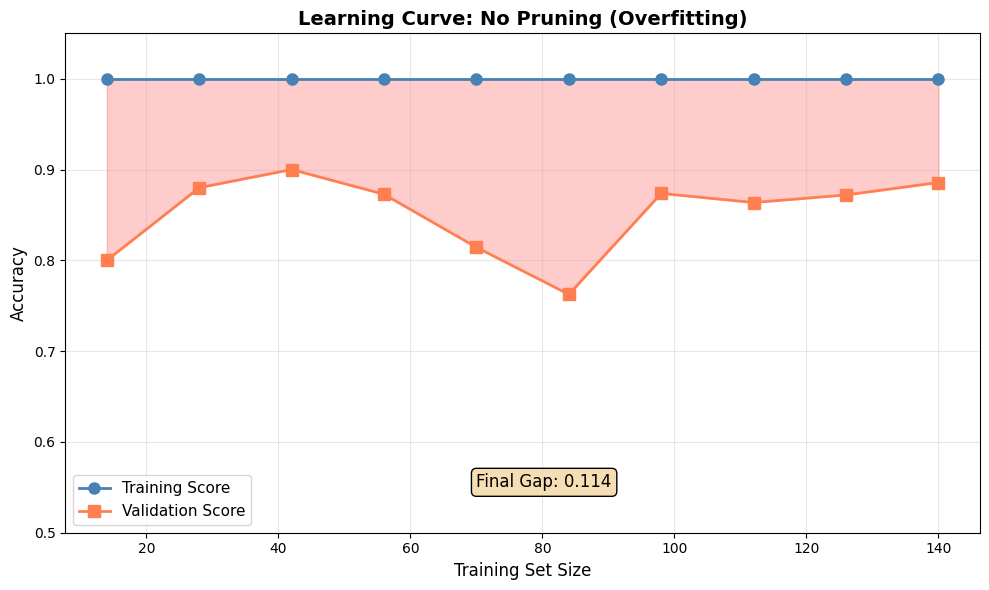


Plotting: Best Parameters (Balanced)


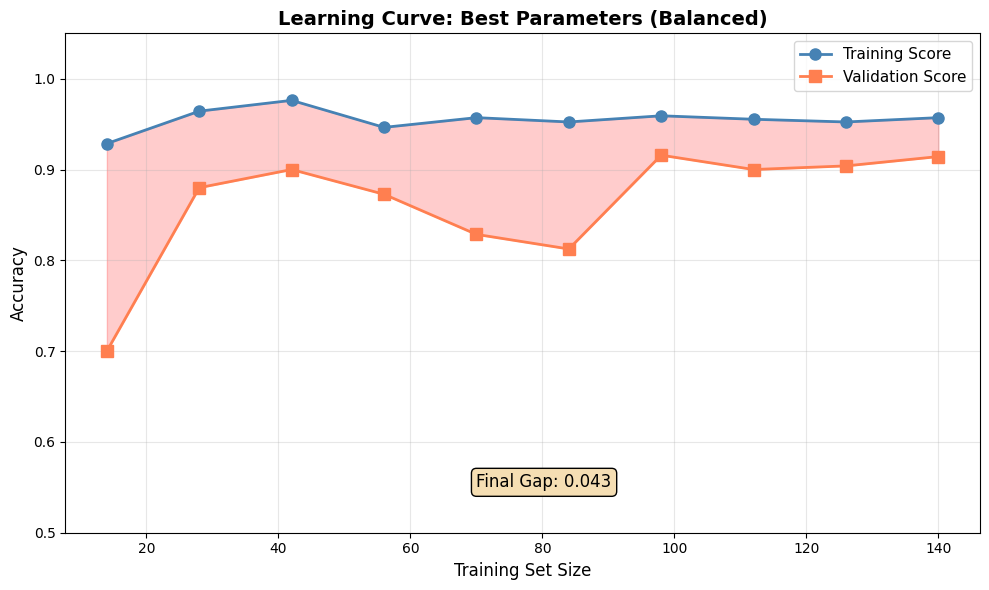


Plotting: Heavy Pruning (Underfitting?)


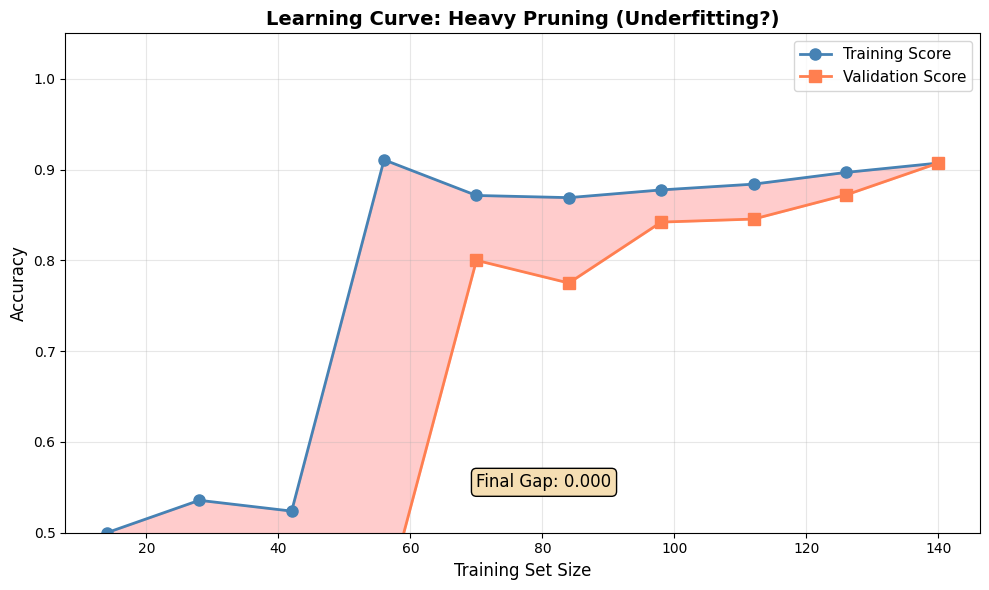


Learning Curves Complete!


In [15]:
# ============================================================
# LEARNING CURVES: DIAGNOSING BIAS VS VARIANCE
# ============================================================
# A LEARNING CURVE answers: "Does my model need MORE DATA or
# a DIFFERENT model?"
#
# HOW IT WORKS:
#   Train the model on 10%, 20%, 30%, ... 100% of the training set.
#   At each size measure BOTH training and validation accuracy.
#   Plot them together and look at the shape.
#
# THREE PATTERNS TO RECOGNISE:
#
# Pattern 1 — HIGH VARIANCE (Overfitting):
#   Train accuracy: HIGH    (~95%)
#   Val accuracy:   LOW     (~75%)
#   Gap:            LARGE   (> 10%)
#   Fix:  Get more data, or add stronger constraints (max_depth, etc.)
#
#   Train |--------------------
#         |
#   Val   |         ___________
#         +---size------------>
#
# Pattern 2 — HIGH BIAS (Underfitting):
#   Train accuracy: LOW  (~75%)
#   Val accuracy:   LOW  (~75%)
#   Gap:            SMALL (both plateau low)
#   Fix:  Use a more complex model (increase depth, fewer constraints)
#
#   Train |     _______________
#   Val   |   _________________
#         +---size------------>
#
# Pattern 3 — JUST RIGHT:
#   Train accuracy: HIGH
#   Val accuracy:   HIGH and CLOSE to train
#   Gap:            SMALL
#   Keep current settings!
# ============================================================

print("\n" + "=" * 60)
print("LEARNING CURVES: Diagnosing Bias vs Variance")
print("=" * 60)


def plot_learning_curves(X, y, params, title):
    """
    Plot training and validation accuracy as the training set grows.

    Args:
        X:      Feature matrix (training data)
        y:      Labels (training data)
        params: Hyperparameter dict for DecisionTreePruned
        title:  String shown in the plot title
    """

    # STEP 1: Define training-set size fractions to test
    # np.linspace(0.1, 1.0, 10) = [0.10, 0.20, 0.30, ..., 1.00]
    train_sizes = np.linspace(0.1, 1.0, 10)

    train_scores = []  # Training accuracy at each size
    val_scores   = []  # Cross-validation accuracy at each size

    for train_size in train_sizes:

        # STEP 2: Take a SLICE of the training data
        # e.g. train_size=0.3 means use 30% of training examples
        n_samples = int(train_size * len(X))
        X_subset  = X[:n_samples]
        y_subset  = y[:n_samples]

        # STEP 3: 5-fold cross-validation on this subset
        # cross_validate_tree returns mean accuracy across 5 folds
        # This gives us an UNBIASED estimate of test performance
        mean_score, _ = cross_validate_tree(X_subset, y_subset, params, k=5)

        # STEP 4: Training accuracy (fit on full subset, predict same data)
        # Will be higher than val because model saw this data!
        tree = DecisionTreePruned(**params)
        tree.fit(X_subset, y_subset)
        train_acc = np.mean(tree.predict(X_subset) == y_subset)

        train_scores.append(train_acc)
        val_scores.append(mean_score)

    # STEP 5: Plot the two curves
    plt.figure(figsize=(10, 6))

    plt.plot(train_sizes * len(X), train_scores, 'o-',
             linewidth=2, markersize=8, label='Training Score', color='steelblue')
    plt.plot(train_sizes * len(X), val_scores, 's-',
             linewidth=2, markersize=8, label='Validation Score', color='coral')

    # Shade the gap between curves — the overfitting zone
    plt.fill_between(train_sizes * len(X), train_scores, val_scores,
                     alpha=0.2, color='red')

    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Learning Curve: {title}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim([0.5, 1.05])

    # Annotate with the final gap size
    final_gap = train_scores[-1] - val_scores[-1]
    plt.text(len(X) * 0.5, 0.55,
             f'Final Gap: {final_gap:.3f}',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat'))

    plt.tight_layout()
    plt.show()


# ============================================================
# PLOT LEARNING CURVES FOR THREE SETUPS
# ============================================================
# 1. No pruning:    expected HIGH VARIANCE (large gap)
# 2. Best params:   expected GOOD FIT (small gap)
# 3. Heavy pruning: expected HIGH BIAS (both curves low)
# ============================================================

configs_to_plot = [
    {
        'params': {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1},
        'title': 'No Pruning (Overfitting)'
    },
    {
        'params': best_params,           # best_params comes from the tuning cell above
        'title': 'Best Parameters (Balanced)'
    },
    {
        'params': {'max_depth': 2, 'min_samples_split': 50, 'min_samples_leaf': 20},
        'title': 'Heavy Pruning (Underfitting?)'
    }
]

for config in configs_to_plot:
    print(f"\nPlotting: {config['title']}")
    plot_learning_curves(X_train, y_train, config['params'], config['title'])

print("\nLearning Curves Complete!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. If val curve is LOW and gap is BIG  -> overfitting
#    Fix: more data OR stronger constraints
#
# 2. If BOTH curves are LOW and gap SMALL -> underfitting
#    Fix: deeper tree, fewer constraints
#
# 3. If BOTH curves are HIGH and gap SMALL -> perfect!
#
# 4. More data ALWAYS helps overfitting but NOT underfitting
#    (if the model is too simple, more data won't help)
#
# 5. Learning curves are one of the most useful debugging tools
#    in all of machine learning!
# ============================================================



VALIDATION CURVE: Analyzing Single Parameter

Analysing max_depth:


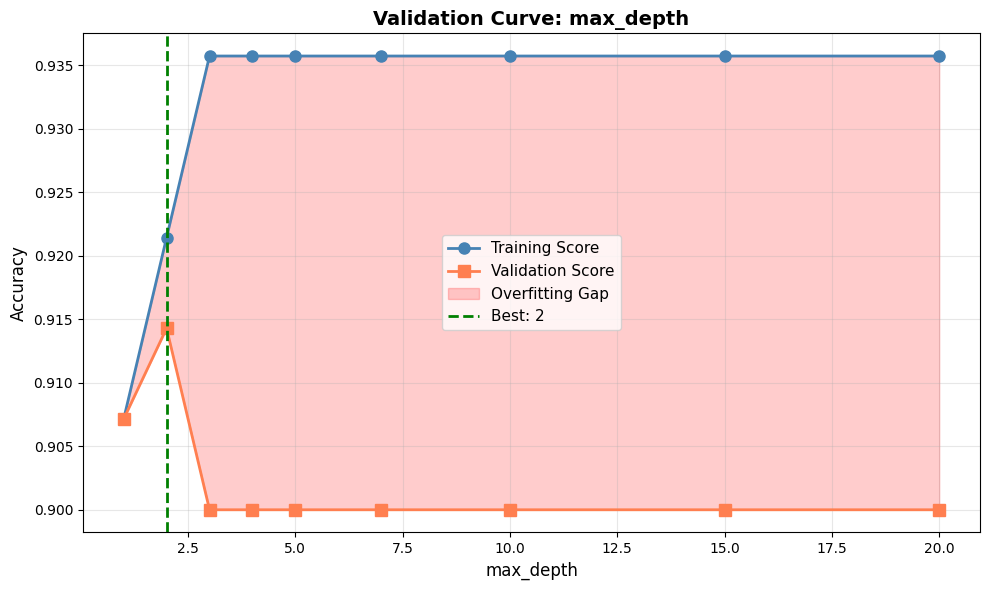

Best max_depth: 2  (CV Score: 0.9143)

Analysing min_samples_split:


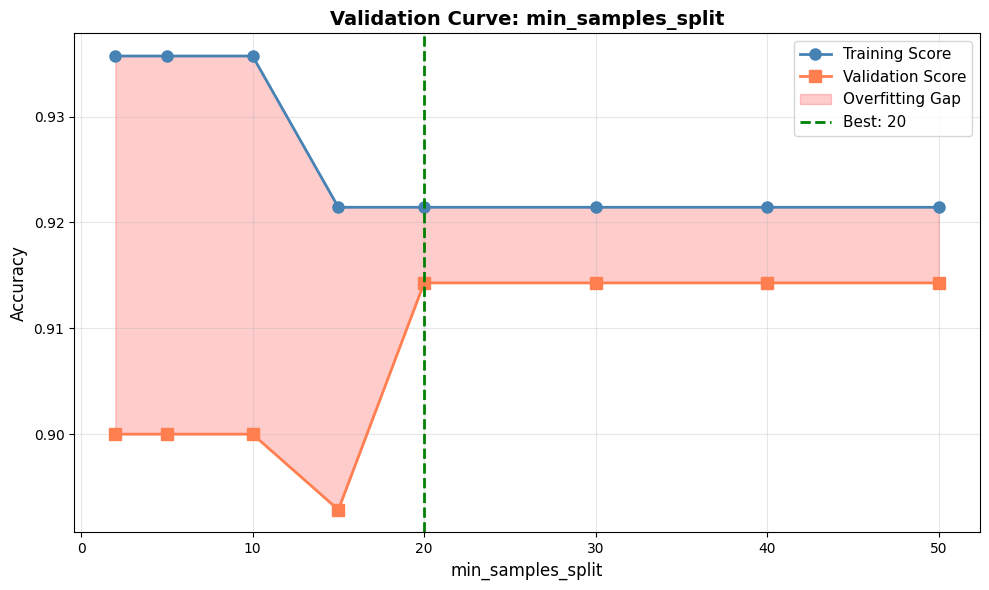

Best min_samples_split: 20  (CV Score: 0.9143)

Validation Curves Complete!


In [16]:
# ============================================================
# VALIDATION CURVE: ANALYSING ONE PARAMETER AT A TIME
# ============================================================
# A VALIDATION CURVE answers: "What is the optimal value
# for a SINGLE hyperparameter?"
#
# HOW IT WORKS:
#   Hold all other hyperparameters fixed.
#   Try many values of ONE parameter (e.g. max_depth = 1..20).
#   At each value measure training AND cross-validation accuracy.
#   Plot them — find the value where val accuracy PEAKS.
#
# TYPICAL SHAPE (for max_depth):
#
#   Accuracy
#     ^
#   1 |  Train .......................
#     |                              .
#  .9 |       Val ----               .
#     |      /        \              .
#  .8 |     /           \___________
#     |    /
#     +---1---3---5---7---10---15---20->
#             ^
#             |
#         Sweet spot (val curve peaks here)
#
# Left of peak  = UNDERFITTING (too shallow / too constrained)
# Right of peak = OVERFITTING  (too deep / too unconstrained)
#
# A vertical green dashed line marks the best value automatically.
# ============================================================

print("\n" + "=" * 60)
print("VALIDATION CURVE: Analyzing Single Parameter")
print("=" * 60)


def plot_validation_curve(X, y, param_name, param_range, fixed_params):
    """
    Plot cross-validation and training accuracy for a range of
    values of ONE hyperparameter (all others held fixed).

    Args:
        X:            Feature matrix
        y:            Labels
        param_name:   Name of the hyperparameter to vary (string)
        param_range:  List of values to try
        fixed_params: Dict of the other hyperparameters (held constant)
    """

    train_scores_mean = []  # Training accuracy at each param value
    val_scores_mean   = []  # CV accuracy at each param value

    for param_value in param_range:

        # STEP 1: Build a params dict with this value plugged in
        params = fixed_params.copy()       # Don't modify the original
        params[param_name] = param_value   # Override the one we're testing

        # STEP 2: Cross-validate to get unbiased accuracy estimate
        mean_score, _ = cross_validate_tree(X, y, params, k=5)

        # STEP 3: Also get training accuracy (will be higher due to overfitting)
        tree = DecisionTreePruned(**params)
        tree.fit(X, y)
        train_score = np.mean(tree.predict(X) == y)

        train_scores_mean.append(train_score)
        val_scores_mean.append(mean_score)

    # STEP 4: Plot both curves
    plt.figure(figsize=(10, 6))

    plt.plot(param_range, train_scores_mean, 'o-',
             linewidth=2, markersize=8, label='Training Score', color='steelblue')
    plt.plot(param_range, val_scores_mean, 's-',
             linewidth=2, markersize=8, label='Validation Score', color='coral')

    # Shade the overfitting gap between train and val
    plt.fill_between(param_range, train_scores_mean, val_scores_mean,
                     alpha=0.2, color='red', label='Overfitting Gap')

    plt.xlabel(param_name, fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Validation Curve: {param_name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    # STEP 5: Mark the best value with a vertical green dashed line
    # np.argmax finds the INDEX of the highest value in the list
    best_idx   = np.argmax(val_scores_mean)
    best_value = param_range[best_idx]

    plt.axvline(x=best_value, color='green', linestyle='--',
                linewidth=2, label=f'Best: {best_value}')
    plt.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"Best {param_name}: {best_value}  (CV Score: {val_scores_mean[best_idx]:.4f})")


# ============================================================
# ANALYSE max_depth
# ============================================================
# Try depths 1, 2, 3, 4, 5, 7, 10, 15, 20.
# All other params are fixed (min_samples_split=10, min_leaf=5).
# We expect val accuracy to peak around 3-5 for this dataset.

print("\nAnalysing max_depth:")
plot_validation_curve(
    X_train, y_train,
    param_name='max_depth',
    param_range=[1, 2, 3, 4, 5, 7, 10, 15, 20],
    fixed_params={'min_samples_split': 10, 'min_samples_leaf': 5}
)

# ============================================================
# ANALYSE min_samples_split
# ============================================================
# Try values 2, 5, 10 ... 50.
# Small value = splits easily (complex) -> overfit risk
# Large value = rarely splits (simple)  -> underfit risk

print("\nAnalysing min_samples_split:")
plot_validation_curve(
    X_train, y_train,
    param_name='min_samples_split',
    param_range=[2, 5, 10, 15, 20, 30, 40, 50],
    fixed_params={'max_depth': 5, 'min_samples_leaf': 5}
)

print("\nValidation Curves Complete!")

# ============================================================
# KEY TAKEAWAYS:
# ============================================================
# 1. The peak of the VAL curve = best parameter value
#
# 2. LEFT of peak:
#    Train AND val both low -> underfitting (model too simple)
#
# 3. RIGHT of peak:
#    Train high, val drops -> overfitting (model too complex)
#
# 4. The GREEN dashed line marks the optimal value automatically
#
# 5. Always use CROSS-VALIDATION score (not training score)
#    to pick the best value — training score always looks too good!
# ============================================================


In [17]:
# ============================================================
# INTERPRETATION GUIDE: READING YOUR DIAGNOSTIC PLOTS
# ============================================================
# This is a REFERENCE CARD you can come back to whenever you
# are confused about what a plot is telling you.
#
# Three types of plots were used in this notebook:
#   1. Learning Curves  (accuracy vs training-set SIZE)
#   2. Validation Curves(accuracy vs one PARAMETER value)
#   3. Heatmap          (accuracy across a 2D parameter GRID)
# ============================================================

print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)

print("""
=============================================================
 LEARNING CURVES  (x-axis = training set SIZE)
=============================================================

What it shows: Does your model need more DATA or a different MODEL?

1. HIGH VARIANCE (Overfitting)
   Training score:   HIGH  (e.g. 97%)
   Validation score: LOW   (e.g. 75%)
   Gap:              LARGE (> 10%)
   Shape:            Train flat-high, val flat-low, big gap
   Diagnosis:        Model memorises training data
   Fix:              Collect more data  OR  add stronger constraints
                     (increase min_samples_split, reduce max_depth)

2. HIGH BIAS (Underfitting)
   Training score:   LOW   (e.g. 75%)
   Validation score: LOW   (e.g. 73%)
   Gap:              SMALL (both plateau near the same low value)
   Shape:            Both curves low and flat
   Diagnosis:        Model is too simple to capture the pattern
   Fix:              Use a deeper tree  OR  relax constraints

3. JUST RIGHT (Good Fit)
   Training score:   HIGH  (e.g. 92%)
   Validation score: HIGH  (e.g. 89%) — close to training score
   Gap:              SMALL (< 5%)
   Fix:              Nothing — keep these settings!

=============================================================
 VALIDATION CURVES  (x-axis = a single PARAMETER value)
=============================================================

What it shows: What is the best value for one hyperparameter?

1. UNDERFITTING REGION  (left / low values)
   Both training and val scores LOW
   Model is too constrained (e.g. max_depth too small)

2. SWEET SPOT  (middle)
   Val score PEAKS here
   Small gap between train and val
   <- This is your optimal parameter value!

3. OVERFITTING REGION  (right / high values)
   Training score HIGH, val score DROPS
   Model is too unconstrained (e.g. max_depth too large)

Rule: Always pick the value where the VALIDATION curve peaks.

=============================================================
 HEATMAP  (2D grid across TWO parameters)
=============================================================

What it shows: How two parameters interact — which COMBINATION is best?

Green  = high accuracy  (good region)
Red    = low accuracy   (bad region)
Star   = best combination found by grid search

Tip: Look for a broad green region (robust setting) not just
     a single bright pixel (might be noise).

=============================================================
""")

print("=" * 60)
print("Complete Hyperparameter Tuning Tutorial Done!")
print("=" * 60)

# ============================================================
# FINAL KEY TAKEAWAYS FOR THE WHOLE NOTEBOOK:
# ============================================================
# 1. Decision Trees are interpretable and powerful, but
#    they need careful HYPERPARAMETER TUNING to avoid overfitting
#
# 2. LEARNING CURVES tell you if you need more data or a better model
#
# 3. VALIDATION CURVES tell you the best value for each parameter
#
# 4. GRID SEARCH + CROSS-VALIDATION is the standard way to
#    systematically find good hyperparameters
#
# 5. ALWAYS evaluate on a HELD-OUT test set at the very end
#    (never use the test set to pick hyperparameters!)
# ============================================================



INTERPRETATION GUIDE

 LEARNING CURVES  (x-axis = training set SIZE)

What it shows: Does your model need more DATA or a different MODEL?

1. HIGH VARIANCE (Overfitting)
   Training score:   HIGH  (e.g. 97%)
   Validation score: LOW   (e.g. 75%)
   Gap:              LARGE (> 10%)
   Shape:            Train flat-high, val flat-low, big gap
   Diagnosis:        Model memorises training data
   Fix:              Collect more data  OR  add stronger constraints
                     (increase min_samples_split, reduce max_depth)

2. HIGH BIAS (Underfitting)
   Training score:   LOW   (e.g. 75%)
   Validation score: LOW   (e.g. 73%)
   Gap:              SMALL (both plateau near the same low value)
   Shape:            Both curves low and flat
   Diagnosis:        Model is too simple to capture the pattern
   Fix:              Use a deeper tree  OR  relax constraints

3. JUST RIGHT (Good Fit)
   Training score:   HIGH  (e.g. 92%)
   Validation score: HIGH  (e.g. 89%) — close to training score

In [18]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


HANDLING CATEGORICAL FEATURES IN DECISION TREES
✓ Encoding functions implemented!

Example Dataset: Customer Purchase Prediction
   Age  Income     City    Education  Purchase
0   56     Low  Chicago       Master       1.0
1   69  Medium    Miami          PhD       1.0
2   46  Medium       LA     Bachelor       1.0
3   32  Medium    Miami       Master       1.0
4   60     Low  Chicago       Master       1.0
5   25     Low      NYC       Master       1.0
6   38     Low       LA     Bachelor       0.0
7   56     Low      NYC  High School       1.0
8   36  Medium      NYC     Bachelor       1.0
9   40  Medium       LA       Master       1.0

Dataset: 200 customers
Purchased: 179.0 (89.5%)

Method 1: Label Encoding

Encoding Mappings:
Income: {'Low': 0, 'Medium': 1, 'High': 2}
City: {'Chicago': 0, 'Miami': 1, 'LA': 2, 'NYC': 3}
Education: {'Master': 0, 'PhD': 1, 'Bachelor': 2, 'High School': 3}

Example rows:
   Income  Income_Encoded     City  City_Encoded Education  Education_Encoded
0  

C:\Users\kesav\AppData\Local\Temp\ipykernel_17348\549775307.py:322: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(methods, rotation=15, ha='right')


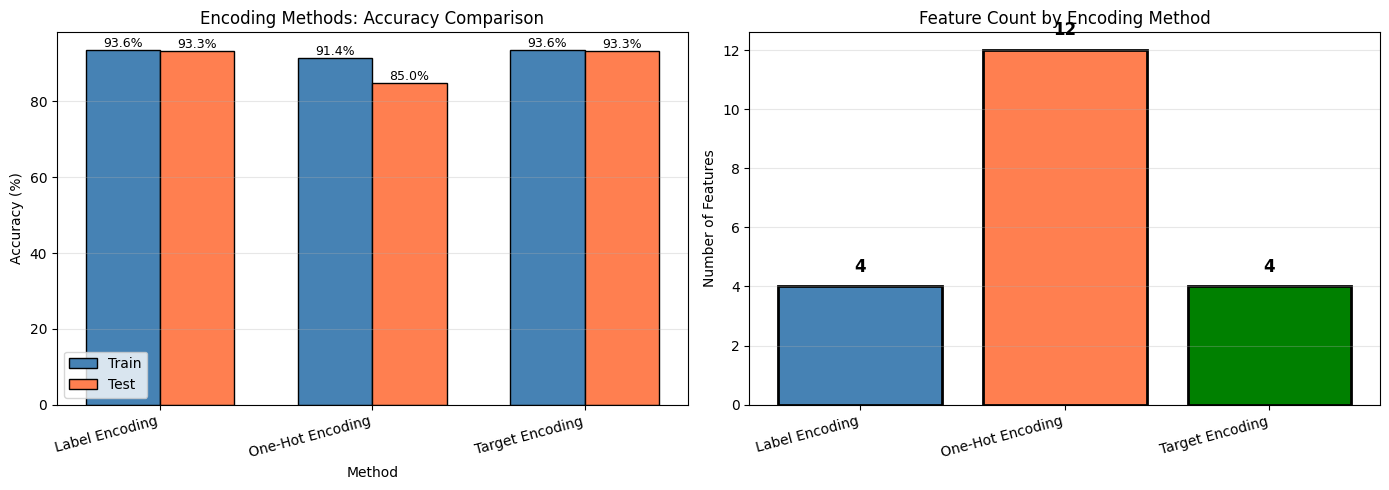


✓ Categorical Feature Encoding Complete!


In [19]:
print("=" * 60)
print("HANDLING CATEGORICAL FEATURES IN DECISION TREES")
print("=" * 60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# HELPER FUNCTIONS FOR ENCODING
# ============================================

def label_encode(series):
    """
    Label encoding: Map categories to integers
    
    Returns:
        encoded: Encoded values
        mapping: Dict mapping categories to integers
    """
    unique_categories = series.unique()
    mapping = {cat: i for i, cat in enumerate(unique_categories)}
    encoded = series.map(mapping)
    return encoded, mapping

def one_hot_encode(series):
    """
    One-hot encoding: Create binary column for each category
    
    Returns:
        DataFrame with binary columns
    """
    return pd.get_dummies(series, prefix=series.name)

def target_encode(series, target, smoothing=1.0):
    """
    Target encoding: Encode based on target mean
    
    Args:
        series: Categorical feature
        target: Target variable
        smoothing: Smoothing factor to prevent overfitting
    
    Returns:
        encoded: Target-encoded values
    """
    # Global mean
    global_mean = target.mean()
    
    # Calculate mean target for each category
    category_means = target.groupby(series).agg(['mean', 'count'])
    
    # Apply smoothing
    smoothed_means = (
        (category_means['mean'] * category_means['count'] + global_mean * smoothing) /
        (category_means['count'] + smoothing)
    )
    
    # Map back to series
    encoded = series.map(smoothed_means)
    
    return encoded

print("✓ Encoding functions implemented!")

# ============================================
# EXAMPLE DATASET WITH CATEGORICAL FEATURES
# ============================================

print("\n" + "=" * 60)
print("Example Dataset: Customer Purchase Prediction")
print("=" * 60)

# Create synthetic dataset
np.random.seed(42)
n = 200

# Features
age = np.random.randint(18, 70, n)
income = np.random.choice(['Low', 'Medium', 'High'], n, p=[0.3, 0.5, 0.2])
city = np.random.choice(['NYC', 'LA', 'Chicago', 'Miami'], n)
education = np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n, p=[0.3, 0.4, 0.2, 0.1])

# Target (purchase decision based on features)
purchase = np.zeros(n)
for i in range(n):
    score = 0
    score += age[i] / 100  # Older → more likely
    score += {'Low': 0, 'Medium': 0.3, 'High': 0.6}[income[i]]
    score += {'NYC': 0.2, 'LA': 0.1, 'Chicago': 0.0, 'Miami': 0.15}[city[i]]
    score += {'High School': 0, 'Bachelor': 0.1, 'Master': 0.2, 'PhD': 0.3}[education[i]]
    score += np.random.randn() * 0.2  # Add noise
    
    purchase[i] = 1 if score > 0.5 else 0

# Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'City': city,
    'Education': education,
    'Purchase': purchase
})

print(df.head(10))
print(f"\nDataset: {len(df)} customers")
print(f"Purchased: {df['Purchase'].sum()} ({df['Purchase'].mean()*100:.1f}%)")

# ============================================
# METHOD 1: LABEL ENCODING
# ============================================

print("\n" + "=" * 60)
print("Method 1: Label Encoding")
print("=" * 60)

df_label = df.copy()

# Encode categorical features
df_label['Income_Encoded'], income_map = label_encode(df_label['Income'])
df_label['City_Encoded'], city_map = label_encode(df_label['City'])
df_label['Education_Encoded'], education_map = label_encode(df_label['Education'])

print("\nEncoding Mappings:")
print(f"Income: {income_map}")
print(f"City: {city_map}")
print(f"Education: {education_map}")

print("\nExample rows:")
print(df_label[['Income', 'Income_Encoded', 'City', 'City_Encoded', 'Education', 'Education_Encoded']].head())

# Prepare features
X_label = df_label[['Age', 'Income_Encoded', 'City_Encoded', 'Education_Encoded']].values
y = df_label['Purchase'].values

# Train/test split
from sklearn.model_selection import train_test_split
X_train_label, X_test_label, y_train, y_test = train_test_split(
    X_label, y, test_size=0.3, random_state=42
)

# Train tree
tree_label = DecisionTreePruned(max_depth=5, min_samples_split=10, min_samples_leaf=5)
tree_label.fit(X_train_label, y_train)

# Evaluate
train_acc_label = np.mean(tree_label.predict(X_train_label) == y_train) * 100
test_acc_label = np.mean(tree_label.predict(X_test_label) == y_test) * 100

print(f"\nLabel Encoding Results:")
print(f"Training accuracy: {train_acc_label:.1f}%")
print(f"Test accuracy: {test_acc_label:.1f}%")

# Feature importance
feature_names_label = ['Age', 'Income_Encoded', 'City_Encoded', 'Education_Encoded']
importances_label = tree_label.feature_importances_

print(f"\nFeature Importances:")
for name, imp in zip(feature_names_label, importances_label):
    print(f"  {name:20s}: {imp:.4f}")

# ============================================
# METHOD 2: ONE-HOT ENCODING
# ============================================

print("\n" + "=" * 60)
print("Method 2: One-Hot Encoding")
print("=" * 60)

df_onehot = df.copy()

# One-hot encode
income_onehot = one_hot_encode(df_onehot['Income'])
city_onehot = one_hot_encode(df_onehot['City'])
education_onehot = one_hot_encode(df_onehot['Education'])

print("\nOne-Hot Encoded Columns:")
print(f"Income: {list(income_onehot.columns)}")
print(f"City: {list(city_onehot.columns)}")
print(f"Education: {list(education_onehot.columns)}")

# Combine all features
X_onehot = pd.concat([
    df_onehot[['Age']],
    income_onehot,
    city_onehot,
    education_onehot
], axis=1).values

print(f"\nFeature matrix shape: {X_onehot.shape}")
print(f"Original: 4 features → After one-hot: {X_onehot.shape[1]} features")

# Train/test split
X_train_onehot, X_test_onehot, y_train, y_test = train_test_split(
    X_onehot, y, test_size=0.3, random_state=42
)

# Train tree
tree_onehot = DecisionTreePruned(max_depth=5, min_samples_split=10, min_samples_leaf=5)
tree_onehot.fit(X_train_onehot, y_train)

# Evaluate
train_acc_onehot = np.mean(tree_onehot.predict(X_train_onehot) == y_train) * 100
test_acc_onehot = np.mean(tree_onehot.predict(X_test_onehot) == y_test) * 100

print(f"\nOne-Hot Encoding Results:")
print(f"Training accuracy: {train_acc_onehot:.1f}%")
print(f"Test accuracy: {test_acc_onehot:.1f}%")

# Feature importance (top 5)
feature_names_onehot = (
    ['Age'] + 
    list(income_onehot.columns) + 
    list(city_onehot.columns) + 
    list(education_onehot.columns)
)
importances_onehot = tree_onehot.feature_importances_

print(f"\nTop 5 Important Features:")
top_indices = np.argsort(importances_onehot)[::-1][:5]
for idx in top_indices:
    print(f"  {feature_names_onehot[idx]:20s}: {importances_onehot[idx]:.4f}")

# ============================================
# METHOD 3: TARGET ENCODING
# ============================================

print("\n" + "=" * 60)
print("Method 3: Target Encoding")
print("=" * 60)

df_target = df.copy()

# Target encode (ONLY on training set to avoid leakage!)
# For demonstration, we'll do it on full dataset
# In practice, compute encoding on train set only!

df_target['Income_Target'] = target_encode(df_target['Income'], df_target['Purchase'])
df_target['City_Target'] = target_encode(df_target['City'], df_target['Purchase'])
df_target['Education_Target'] = target_encode(df_target['Education'], df_target['Purchase'])

print("\nTarget Encoding Values:")
print(f"\nIncome:")
print(df_target.groupby('Income')['Income_Target'].first())
print(f"\nCity:")
print(df_target.groupby('City')['City_Target'].first())
print(f"\nEducation:")
print(df_target.groupby('Education')['Education_Target'].first())

# Prepare features
X_target = df_target[['Age', 'Income_Target', 'City_Target', 'Education_Target']].values

# Train/test split
X_train_target, X_test_target, y_train, y_test = train_test_split(
    X_target, y, test_size=0.3, random_state=42
)

# Train tree
tree_target = DecisionTreePruned(max_depth=5, min_samples_split=10, min_samples_leaf=5)
tree_target.fit(X_train_target, y_train)

# Evaluate
train_acc_target = np.mean(tree_target.predict(X_train_target) == y_train) * 100
test_acc_target = np.mean(tree_target.predict(X_test_target) == y_test) * 100

print(f"\nTarget Encoding Results:")
print(f"Training accuracy: {train_acc_target:.1f}%")
print(f"Test accuracy: {test_acc_target:.1f}%")

# ============================================
# COMPARISON
# ============================================

print("\n" + "=" * 60)
print("COMPARISON: All Three Methods")
print("=" * 60)

methods = ['Label Encoding', 'One-Hot Encoding', 'Target Encoding']
train_accs = [train_acc_label, train_acc_onehot, train_acc_target]
test_accs = [test_acc_label, test_acc_onehot, test_acc_target]
n_features = [4, X_onehot.shape[1], 4]

comparison_df = pd.DataFrame({
    'Method': methods,
    'Train Acc': train_accs,
    'Test Acc': test_accs,
    'Features': n_features
})

print(comparison_df)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
x = np.arange(len(methods))
width = 0.35

bars1 = ax1.bar(x - width/2, train_accs, width, label='Train', color='steelblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, test_accs, width, label='Test', color='coral', edgecolor='black')

ax1.set_xlabel('Method')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Encoding Methods: Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(methods, rotation=15, ha='right')
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Feature count comparison
ax2.bar(methods, n_features, color=['steelblue', 'coral', 'green'], 
        edgecolor='black', linewidth=2)
ax2.set_ylabel('Number of Features')
ax2.set_title('Feature Count by Encoding Method')
ax2.set_xticklabels(methods, rotation=15, ha='right')
ax2.grid(True, axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(n_features):
    ax2.text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Categorical Feature Encoding Complete!")

In [20]:
print("\n" + "=" * 60)
print("POST-PRUNING DEMONSTRATION")
print("=" * 60)

# This is conceptual - full implementation is complex
# Showing the idea with sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Use our customer data from earlier
X = df[['Age']].values  # Just age for simplicity
X = np.column_stack([X, df_label['Income_Encoded'].values])
y = df['Purchase'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")  
print(f"Test: {len(X_test)} samples")

# ============================================
# METHOD 1: PRE-PRUNING ONLY
# ============================================

print("\n" + "=" * 60)
print("Pre-Pruning Only (max_depth)")
print("=" * 60)

tree_pre = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_pre.fit(X_train, y_train)

train_acc_pre = tree_pre.score(X_train, y_train) * 100
val_acc_pre = tree_pre.score(X_val, y_val) * 100
test_acc_pre = tree_pre.score(X_test, y_test) * 100

print(f"Tree depth: {tree_pre.get_depth()}")
print(f"Number of leaves: {tree_pre.get_n_leaves()}")
print(f"Training accuracy: {train_acc_pre:.1f}%")
print(f"Validation accuracy: {val_acc_pre:.1f}%")
print(f"Test accuracy: {test_acc_pre:.1f}%")

# ============================================
# METHOD 2: POST-PRUNING (Cost-Complexity)
# ============================================

print("\n" + "=" * 60)
print("Post-Pruning (Cost-Complexity with ccp_alpha)")
print("=" * 60)

# First, grow full tree to get pruning path
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Get cost-complexity pruning path
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f"Full tree depth: {tree_full.get_depth()}")
print(f"Full tree leaves: {tree_full.get_n_leaves()}")
print(f"Testing {len(ccp_alphas)} different alpha values...")

# Try different alpha values
best_alpha = 0
best_val_acc = 0

for alpha in ccp_alphas[:-1]:  # Skip last (fully pruned tree)
    tree_post = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    tree_post.fit(X_train, y_train)
    
    val_acc = tree_post.score(X_val, y_val)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha:.6f}")

# Train final tree with best alpha
tree_post_final = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
tree_post_final.fit(X_train, y_train)

train_acc_post = tree_post_final.score(X_train, y_train) * 100
val_acc_post = tree_post_final.score(X_val, y_val) * 100
test_acc_post = tree_post_final.score(X_test, y_test) * 100

print(f"\nPost-Pruned Tree:")
print(f"Tree depth: {tree_post_final.get_depth()}")
print(f"Number of leaves: {tree_post_final.get_n_leaves()}")
print(f"Training accuracy: {train_acc_post:.1f}%")
print(f"Validation accuracy: {val_acc_post:.1f}%")
print(f"Test accuracy: {test_acc_post:.1f}%")

# ============================================
# COMPARISON
# ============================================

print("\n" + "=" * 60)
print("PRE-PRUNING vs POST-PRUNING COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Method': ['Pre-Pruning', 'Post-Pruning'],
    'Depth': [tree_pre.get_depth(), tree_post_final.get_depth()],
    'Leaves': [tree_pre.get_n_leaves(), tree_post_final.get_n_leaves()],
    'Train Acc': [train_acc_pre, train_acc_post],
    'Val Acc': [val_acc_pre, val_acc_post],
    'Test Acc': [test_acc_pre, test_acc_post]
})

print(comparison)

print("\n" + "=" * 60)
print("Key Observations:")
print("=" * 60)
print("• Post-pruning can discover optimal complexity automatically")
print("• Pre-pruning is simpler but might miss optimal depth")
print("• Difference is often small (1-2%)")
print("• In practice, both work well!")

print("\n✓ Post-Pruning Demonstration Complete!")


POST-PRUNING DEMONSTRATION
Training: 120 samples
Validation: 40 samples
Test: 40 samples

Pre-Pruning Only (max_depth)
Tree depth: 5
Number of leaves: 16
Training accuracy: 93.3%
Validation accuracy: 82.5%
Test accuracy: 92.5%

Post-Pruning (Cost-Complexity with ccp_alpha)
Full tree depth: 7
Full tree leaves: 21
Testing 14 different alpha values...

Best alpha: 0.009029

Post-Pruned Tree:
Tree depth: 3
Number of leaves: 4
Training accuracy: 90.8%
Validation accuracy: 90.0%
Test accuracy: 95.0%

PRE-PRUNING vs POST-PRUNING COMPARISON
         Method  Depth  Leaves  Train Acc  Val Acc  Test Acc
0   Pre-Pruning      5      16  93.333333     82.5      92.5
1  Post-Pruning      3       4  90.833333     90.0      95.0

Key Observations:
• Post-pruning can discover optimal complexity automatically
• Pre-pruning is simpler but might miss optimal depth
• Difference is often small (1-2%)
• In practice, both work well!

✓ Post-Pruning Demonstration Complete!


In [ ]:
# ============================================
# COMPLETE DECISION TREE WORKFLOW
# (As designed by you!)
# ============================================

# Step 1: Mixed encoding strategy
def preprocess_features(df):
    # One-hot: Low cardinality nominal
    city_encoded = pd.get_dummies(df['City'], prefix='City')
    dept_encoded = pd.get_dummies(df['Department'], prefix='Dept')
    
    # Label: Ordinal features
    education_map = {'HS': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
    df['Education_Enc'] = df['Education'].map(education_map)
    
    income_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df['Income_Enc'] = df['Income'].map(income_map)
    
    # Target: High cardinality
    df['JobTitle_Enc'] = target_encode(df['JobTitle'], df['target'])
    
    # Combine
    X = pd.concat([
        df[numerical_features],  # 20 original features
        city_encoded,
        dept_encoded,
        df[['Education_Enc', 'Income_Enc', 'JobTitle_Enc']]
    ], axis=1)
    
    return X

# Step 2: Initial feature selection
X = preprocess_features(df)
y = df['target']

tree_initial = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_initial.fit(X, y)

# Remove low-importance features
important_mask = tree_initial.feature_importances_ >= 0.01
X_selected = X.loc[:, important_mask]
print(f"Reduced from {X.shape[1]} to {X_selected.shape[1]} features")

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Cross-validation for hyperparameters
param_grid = {
    'max_depth': [5, 7, 10, 15],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print(f"Best params: {grid.best_params_}")
print(f"CV accuracy: {grid.best_score_:.3f}")

# Step 5: Learning curve analysis
train_sizes, train_scores, val_scores = learning_curve(
    best_tree, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Check for overfitting
gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
if gap > 0.05:
    print("⚠️ Overfitting - consider post-pruning")
    
    # Step 6: Post-pruning (if needed)
    path = best_tree.cost_complexity_pruning_path(X_train, y_train)
    
    # Find best alpha via CV
    best_alpha = 0
    best_score = 0
    for alpha in path.ccp_alphas:
        tree_pruned = DecisionTreeClassifier(
            **grid.best_params_, 
            ccp_alpha=alpha
        )
        scores = cross_val_score(tree_pruned, X_train, y_train, cv=5)
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_alpha = alpha
    
    # Final model with post-pruning
    final_tree = DecisionTreeClassifier(
        **grid.best_params_,
        ccp_alpha=best_alpha
    )
    final_tree.fit(X_train, y_train)
else:
    print("✓ Good fit - using pre-pruned tree")
    final_tree = best_tree

# Step 7: Final evaluation
test_acc = final_tree.score(X_test, y_test)
print(f"\nFinal test accuracy: {test_acc:.3f}")
print(f"Tree depth: {final_tree.get_depth()}")
print(f"Number of leaves: {final_tree.get_n_leaves()}")